<img src="../workshops/img/swdb_logo.jpg">

<h1 align="center">Connectomics Module 1: Neuron-centered connectomics</h1>
<h2 align="center">SOLUTIONS</h2>
<h3 align="center">Summer Workshop on the Dynamic Brain 2026</h3>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>The function of the nervous system arises out of a combination of the properties of individual neurons and the properties of how they are connected into a larger network. The central goal of <b>connectomics</b> is to produce complete maps of the connectivity of the nervous system with synaptic resolution and analyze them to better understand the organization, development, and function of the nervous system.
<p>Electron Microscopy (EM) data enables morphological reconstruction of neurons and resolution of their synaptic connectivity. The V1DD dataset is one of the largest volume EM datasets currently available, and spans all layers of mouse visual cortex. We will be using this dataset to query the connectivity between neurons in the visual cortex.
<p>The V1DD dataset is newly public. Previous years of this course have used the <a href="https://www.microns-explorer.org/">MICrONS Dataset</a>, which is also a cubic millimeter volume of mouse visual cortex. Both datasets are available for the use of this course, but we will cover V1DD in Week 1.
<p>Module 1 of this workshop will:
<ul>
<li>introduce the basics of how synaptic connectivity is measured in EM connectomics
<li>examine reconstructions of individual neurons and their connectivity
<li>discuss how morphological features and connectivity suggest cell types
<li>explore how connectivity changes as function of target and distance
</ul>
<p>Module 2 of this workshop will:
<ul>
<li>introduce concepts of network connectivity
<li>investigate the role of cell type in the structure of networks
<li>consider connection probability as a function of distance
<li>incorporate ophys recordings and map the correlation of structure to function
</ul>

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Setup </h2>
<p>Everything in this notebook comes from CAVE, the live annotation database, rather than from a file on disk. That means there is no data path to configure, but it does mean you need an authentication token, which the next section sets up.

</div>

In [1]:
# Import packages
import pandas as pd
import numpy as np

import ossify as osy
from standard_transform.datasets import v1dd_ds

from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

/opt/conda/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.2) or chardet (7.6.0)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> CAVE account setup </h2>
<p>In order to manage server traffic, every user needs to create a CAVE account and download a user token to access CAVE's services programmatically. The CAVE infrastructure can be read about in more detail in the <a href="https://doi.org/10.1038/s41592-024-02426-z">MICrONS Nature Package</a>.
<p><b>A Google account (or Google-enabled account) is required to create a CAVE account.</b>
<p>Run the cell below and follow the set up instructions; enter the token first, then enter 'y' when prompted

</div>

In [2]:
from caveclient import CAVEclient

# Token Generation and Setup
CAVEclient.setup_token("https://global.em.brain.allentech.org")

# Initialize CAVEclient
client = CAVEclient(datastack_name="v1dd_public")

Visit https://global.em.brain.allentech.org/sticky_auth/settings/tokens and copy an existing token or create a new one.


Paste your auth token (input will be hidden):  ········
Set all of your datastacks to use this token and server ('Y', recommended), specify individual datastacks ('n'), or finish now ('exit'). (Y/n/exit)  y


All datastacks are configured to use this server address.
You will not need to specify a server address when initializing a client for configured datastacks in the future.
Setup complete!


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p><b>Tip for CodeOcean users:</b> you can add the the CAVEclient token to your capsule's secrets, so you do not have to enter it every time you run the notebook. If you chose to use EM data for your project in Week 2, <a href="https://allenswdb.github.io/anatomy/microns-em/em-caveclient-setup.html#codeocean-token-setup">check out the DataBook for instruction</a>

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Neuron morphology: representing neurons as skeletons </h2>
<p>Often in thinking about neurons, you want to measure things along a linear dimension of a neuron.
<p>However, the segmentation and meshes are a complex 3D shape that makes this non-trivial. There are methods for reducing the shape of a segmented neuron down to a linear tree like structure usually referred to as a <b>skeleton</b>. CAVE <code>Skeleton Service</code> automatically generates skeletons for a large number of cells in the dataset, and makes the skeleton generation available on demand.
<br>
<img src="../workshops/img/swdb_mesh_skeleton.png" width="800">
</br>
<p><i>Note</i>: The meshes you see in Neuroglancer are available to download through the python client <code>cloud-volume</code>, and can be loaded for analysis and visualization in other tools. This is useful for some types of analysis (and for making beautiful renders of neurons), but we will not cover that in this course.
<p>Now we will select one neuron based on its root_id, the 18-digit number you see in neuroglancer (like we will do later)

</div>

In [3]:
# Load basic cell (skeleton + L2 graph)
root_id = 864691132534315610 # Known example neuron. You may iterate later. 

cell = osy.load_cell_from_client(
    root_id=root_id,
    client=client,
)

print(f"Loaded cell {cell.name}")
print(f"Skeleton: {cell.skeleton.n_vertices} vertices")

Loaded cell 864691132534315610
Skeleton: 3567 vertices


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>The python package <code>ossify</code> provides skeleton downloading, processing, analysis, and many convenience functions. Including loading cells directly from connectomics databases using CAVEclient. For documentation, see <a href="https://csdashm.com/ossify/">Ossify</a>.
<p>Then we can use the <code>plot_morphology_2d</code> function to visualize our neuron in two dimensions:

</div>

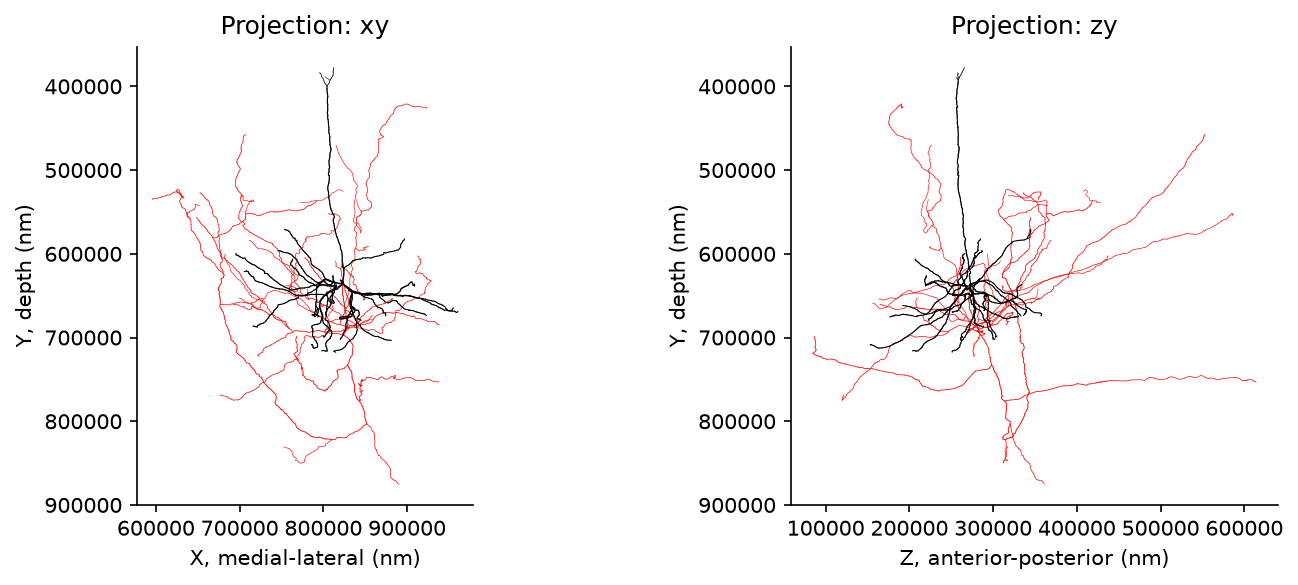

In [4]:
# Figure 1: Skeleton representation in 2D

# Plot different 2D projections
projections = ["xy", "zy"] # , 'xz']
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

for i, proj in enumerate(projections):
    osy.plot.plot_morphology_2d(
        cell,
        projection=proj,
        color="compartment",
        # Compartment codes are SWC conventions; use the names rather than 1/2/3
        palette={osy.SWC_DENDRITE: "black", osy.SWC_AXON: "red"},
        linewidth="radius",          # thicker where the neurite is thicker
        linewidth_norm=(100, 1000),  # radii in nm that map to the width range below
        widths=(0.25, 2),
        ax=axes[i]
    )
    axes[i].set_title(f"Projection: {proj}")
    axes[i].set_aspect("equal")

# Add labels for the anatomical orientation
axes[0].set(xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
axes[1].set(xlabel='Z, anterior-posterior (nm)', ylabel='Y, depth (nm)')
sns.despine()
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h4> Transformed coordinate system </h4>
<p>A note on the coordinate frame: the <i>native resolution</i> for V1DD is in units of <i>voxels</i>. The data you will see in neuroglancer is in Voxel space where each coordinate is in the thousands. Not only are these units large, the offset is arbitrary. We want more comprehensible numbers for comparison. It makes much more sense to anchor y=0 to the pial surface and use 'real' coordinates.
<p>The skeleton above is plotted in <b>nanometer coordinates</b>, which differs from neuroglancer. In general, there are three types of coordinates you may encounter and it is worth being deliberate in which system you use.
<ol>
<li><b>Voxel coordinates</b> are the coordinates of a point in the original image volume. These are the coordinates that are used to index into the volumes you can see in Neuroglancer, but each number has a potentially different unit. In the V1DD data, a voxel is 9 nm wide in the x and y directions, and 45 nm long in the z direction. This means that a 1x1x1 micron cube would be represented by a ~110x110x20 voxel span. Annotations (such as synapses) are stored in voxel coordinates.
<li><b>Nanometer coordinates</b> are the coordinates of a point in the original image volume, but in nanometers. This is equivalent to the voxel coordinate multiplied by the voxel resolution, with no further transformation applied. Mesh and skeleton vertices are stored in nanometer coordinates.
<li><b>Transformed coordinates</b> reflect a transformation that has been applied to the original image volume. This transformation is a rotation to make the pia surface as flat as possible, a translation to move the pial surface to y=0, and a scaling to bring coordinates into microns. Transformed coordinates are convenient for more accurate computations of depth and the pia-to-white-matter axis, but are not stored by default. For documentation, see <a href="https://caveconnectome.github.io/standard_transform/">Standard Transform</a>.
</ol>
<p>You will encounter more neuron-centered representations of space later in the module.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Rather than take that on faith, apply the transform and plot the same cell again. <code>v1dd_ds.transform("nm")</code> builds the transform for this dataset and declares that the <i>input</i> coordinates are nanometers; <code>cell.transform(...)</code> returns a new cell with every vertex moved, leaving the original untouched.
<p>Compare the axes with Figure 1. The shape is the same — it is the same neuron — but the numbers are now microns of depth below the pia, so "this synapse is at 250 µm" means something anatomical rather than something about where the volume happened to be cropped.
<p>Every figure from here on uses transformed coordinates.

</div>

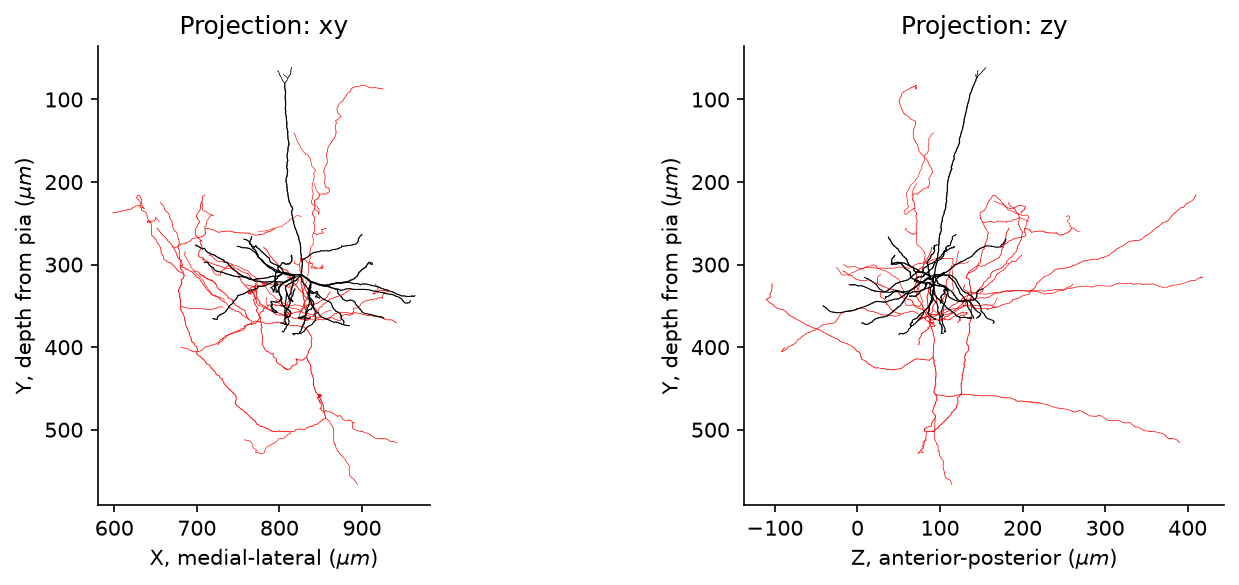

In [5]:
# Figure 1b: the same skeleton in transformed coordinates

# One transform object, reused for the rest of the notebook. "nm" says what goes in.
tform = v1dd_ds.transform("nm")

cell_um = cell.transform(tform.apply)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

for i, proj in enumerate(["xy", "zy"]):
    osy.plot.plot_morphology_2d(
        cell_um,
        projection=proj,
        color="compartment",
        palette={osy.SWC_DENDRITE: "black", osy.SWC_AXON: "red"},
        linewidth="radius",
        linewidth_norm=(100, 1000),
        widths=(0.25, 2),
        ax=axes[i]
    )
    axes[i].set_title(f"Projection: {proj}")
    axes[i].set_aspect("equal")

axes[0].set(xlabel=r'X, medial-lateral ($\mu m$)', ylabel=r'Y, depth from pia ($\mu m$)')
axes[1].set(xlabel=r'Z, anterior-posterior ($\mu m$)', ylabel=r'Y, depth from pia ($\mu m$)')
sns.despine()
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Adding synapse positions to skeleton </h3>
<p>Synapses are automatically detected and assigned in the dataset. That means we <i>nominally</i> know all of the inputs to and outputs from our cell of interest — with an important caveat we will come to shortly. Let's collect that data:
<p><b>Note</b> this cell may take a minute to run. It is pulling more data than the previous code <code>load_cell</code> call

</div>

In [6]:
# Load skeleton with synaptic features
root_id = 864691132534315610 # Known example neuron. You may iterate later. 

cell = osy.load_cell_from_client(
    root_id=root_id,
    client=client,
    synapses=True, # optional argument to load synapses with skeleton
    include_partner_root_id=True, # optional argument to load partner root ids with synapses
)

print(f"Loaded cell {cell.name}")
print(f"Skeleton: {cell.skeleton.n_vertices} vertices")

# All annotations in the cell
cell.annotations.describe()

Loaded cell 864691132534315610
Skeleton: 3567 vertices
# Annotations (2)
├── pre_syn (PointCloudLayer)
│   ├── 673 vertices
│   ├── features: [created, deleted, post_pt_position_x, post_pt_position_y, post_pt_position_z, post_pt_root_id, 
│       post_pt_supervoxel_id, pre_pt_l2_id, pre_pt_position_x, pre_pt_position_y, pre_pt_position_z, pre_pt_root_id, 
│       pre_pt_supervoxel_id, size]
│   └── Links: graph <-> pre_syn
└── post_syn (PointCloudLayer)
    ├── 1091 vertices
    ├── features: [created, deleted, post_pt_l2_id, post_pt_position_x, post_pt_position_y, post_pt_position_z, 
│       post_pt_root_id, post_pt_supervoxel_id, pre_pt_position_x, pre_pt_position_y, pre_pt_position_z, pre_pt_root_id, 
│       pre_pt_supervoxel_id, size]
    └── Links: graph <-> post_syn


In [7]:
# Show the synapse dataframe attached to skeleton
pre_syn_df = cell.annotations.pre_syn.nodes
post_syn_df = cell.annotations.post_syn.nodes

# return the available columns to line
print(pre_syn_df.columns)

pre_syn_df.head(3)

Index(['created', 'deleted', 'pre_pt_position_x', 'pre_pt_position_y',
       'pre_pt_position_z', 'post_pt_position_x', 'post_pt_position_y',
       'post_pt_position_z', 'ctr_pt_position_x', 'ctr_pt_position_y',
       'ctr_pt_position_z', 'size', 'pre_pt_supervoxel_id', 'pre_pt_root_id',
       'post_pt_supervoxel_id', 'post_pt_root_id', 'pre_pt_l2_id'],
      dtype='object')


,created,deleted,pre_pt_position_x,pre_pt_position_y,pre_pt_position_z,post_pt_position_x,post_pt_position_y,post_pt_position_z,ctr_pt_position_x,ctr_pt_position_y,ctr_pt_position_z,size,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_l2_id
id,,,,,,,,,,,,,,,,,
402558233,2021-11-18 22:05:28.270700+00:00,NaT,839602,564646,228735,839515,565160,229410,839699.0,565034.0,229095.0,3881.0,93320500256229717,864691132534315610,93320568975740637,864691132726874269,165378094293583076
292446107,2021-11-18 22:06:23.833563+00:00,NaT,675478,569525,361440,675333,569700,361125,675469.0,569603.0,361305.0,1082.0,88676300981986694,864691132534315610,88676300981976915,864691132620269499,160733895019463949
438169048,2021-11-18 22:08:20.896586+00:00,NaT,865899,475571,202005,865725,476095,202230,865695.0,475872.0,202005.0,5146.0,94021782449115055,864691132534315610,94021782449121473,864691132569299996,166079376486565024


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h4> Call back: consistent coordinate system transform </h4>
<p>We'll apply the <code>standard_transform</code> now so it doesn't surprise us later

</div>

In [8]:
# Put the skeleton and the synapses in the same (transformed) space before plotting them together
cell_um = cell.transform(tform.apply)

# Synapse positions arrive in nanometers, same as the skeleton vertices, so they take the
# same transform. `ctr_pt_position` is the center of the synapse; apply_dataframe finds
# the _x/_y/_z columns for us.
for df in (pre_syn_df, post_syn_df):
    df["syn_x_um"] = tform.apply_dataframe("ctr_pt_position", df, projection="x")
    df["syn_y_um"] = tform.apply_dataframe("ctr_pt_position", df, projection="y")
    df["syn_z_um"] = tform.apply_dataframe("ctr_pt_position", df, projection="z")

post_syn_df[["ctr_pt_position_x", "ctr_pt_position_y", "syn_x_um", "syn_y_um"]].head(3)

,ctr_pt_position_x,ctr_pt_position_y,syn_x_um,syn_y_um
id,,,,
405315773,830717.0,643333.0,834.118076,328.754625
395011063,815770.0,577247.0,818.812965,253.579560
440332672,872738.0,655322.0,876.195566,339.048801


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Examine the synapses for a cell of interest </h3>

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Now we have all the synapses associated with this cell, where its <code>pt_root_id</code> shows up as either the <i>presynaptic</i> id or the <i>postsynaptic</i> id. The dataframe returned above includes a lot of bookkeeping columns we don't care about. We will narrow our focus down to 5 classes of column:
<ul>
<li><code>id</code> : the <i>synapse id</i> which is unique to every detected synapse and is immutable.
<li><code>pre_pt_root_id</code> , <code>post_pt_root_id</code> : the segmentation id or <code>root_id</code> for the object on either side of the synapse. This may be a neuron, a fragment of a neuron, or a non-neuronal object. This is the id unique to the segmented object at that time, but will change with proofreading.
<li><code>size</code> : the size of the synaptic cleft in units of voxels. This is an output of the automated synapse detection, and is generally a useful low-level feature for other analysis.
<li><code>ctr_pt_position_x</code>, <code>ctr_pt_position_y</code>, <code>ctr_pt_position_z</code>: the mid-point position of the synapse in units of <code>nm</code>. The position metric we generally use, though two other types of position exist: <code>pre_pt</code> and <code>post_pt</code> which are useful if you need the point to land on either the presynaptic or postsynaptic segment, respectively.
<li><code>syn_x_um</code>, <code>syn_y_um</code>, <code>syn_z_um</code>: our applied transformation from standard_transform, putting the units in transformed_um.
</ul>

</div>

In [9]:
post_syn_df.head(3)[['pre_pt_root_id','post_pt_root_id','size','ctr_pt_position_x','ctr_pt_position_y','ctr_pt_position_z','syn_x_um','syn_y_um','syn_z_um']]

,pre_pt_root_id,post_pt_root_id,size,ctr_pt_position_x,ctr_pt_position_y,ctr_pt_position_z,syn_x_um,syn_y_um,syn_z_um
id,,,,,,,,,
405315773,864691131677275322,864691132534315610,1707.0,830717.0,643333.0,308385.0,834.118076,328.754625,125.484344
395011063,864691132921086475,864691132534315610,465.0,815770.0,577247.0,265140.0,818.812965,253.579560,101.497568
440332672,864691132578941970,864691132534315610,933.0,872738.0,655322.0,304470.0,876.195566,339.048801,118.531462


In [10]:
pre_syn_df.head(3)[['pre_pt_root_id','post_pt_root_id','size','ctr_pt_position_x','ctr_pt_position_y','ctr_pt_position_z','syn_x_um','syn_y_um','syn_z_um']]

,pre_pt_root_id,post_pt_root_id,size,ctr_pt_position_x,ctr_pt_position_y,ctr_pt_position_z,syn_x_um,syn_y_um,syn_z_um
id,,,,,,,,,
402558233,864691132534315610,864691132726874269,3881.0,839699.0,565034.0,229095.0,842.656411,232.044611,70.053451
292446107,864691132534315610,864691132620269499,1082.0,675469.0,569603.0,361305.0,678.540945,272.654867,196.104130
438169048,864691132534315610,864691132569299996,5146.0,865695.0,475872.0,202005.0,868.189882,138.756608,67.836993


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h4>  What is input or output? How can we tell? </h4>

<p>Look at the two tables above. Both have a <code>pre_pt_root_id</code> and a <code>post_pt_root_id</code> column, because a synapse is a directed thing: it runs <i>from</i> the presynaptic neuron <i>to</i> the postsynaptic neuron. Neither column is "our" cell by definition — which one holds our root id is exactly what tells us which direction we are looking at.
<p>In the first table, <code>post_pt_root_id</code> is <code>864691132534315610</code> on every row: our cell is the one receiving. Those are its <b>inputs</b>.
<p>In the second, <code>pre_pt_root_id</code> is our cell on every row: it is the one sending. Those are its <b>outputs</b>.
<p>The annotation ossify calls <code>post_syn</code> is the one where our cell is the <i>post</i>synaptic partner — so <code>post_syn</code> holds the <b>inputs</b>, and <code>pre_syn</code> holds the <b>outputs</b>. Read the name as "which side of the synapse our cell is on", not "which direction the information flows". Getting this backwards silently swaps every result in the rest of the notebook.
<p>We can check your answer by plotting the synapse positions on the skeleton:
    
</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Exercise 1: Plot synapses on skeleton</b>

<p>First, give the synapse dataframes unambiguous names. Test your assignment by plotting the synapses on the skeleton.

</div>

In [11]:
# Assign the synapse dataframes to the correct variable
input_df = post_syn_df # where our neuron is the POSTsynaptic cell
output_df  = pre_syn_df # where our neuron is the PREsynaptic cell

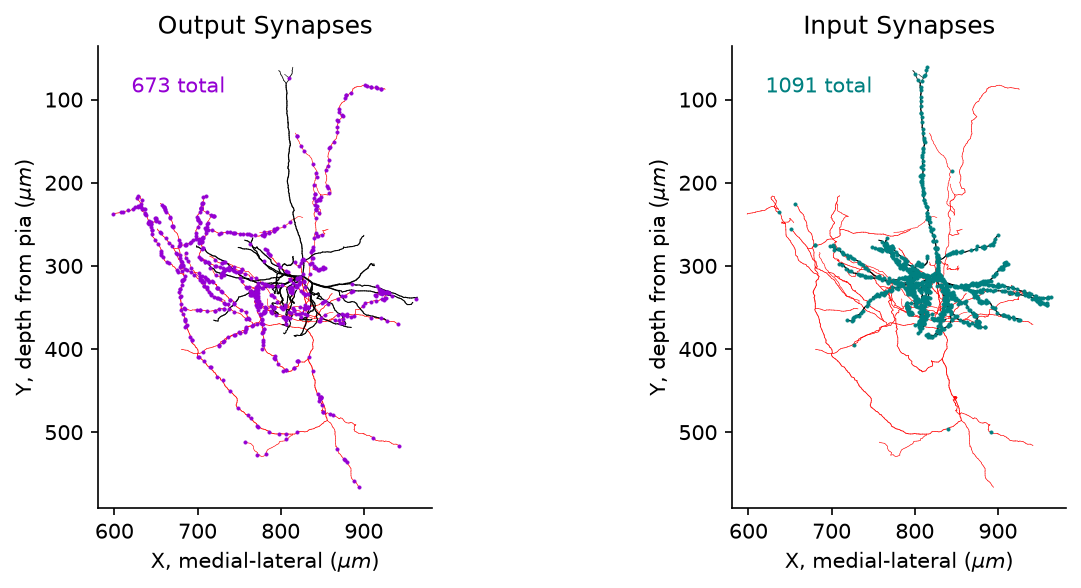

In [12]:
# Figure 2: Skeleton with synaptic inputs and outputs

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

for i in range(2):
    osy.plot.plot_morphology_2d(cell_um,
                                projection="xy",
                                color="compartment",
                                palette={osy.SWC_DENDRITE: "black", osy.SWC_AXON: "red"},
                                linewidth="radius",
                                linewidth_norm=(100, 1000),
                                widths=(0.25, 2),
                                ax=ax[i])

# Output synapses
sns.scatterplot(data=output_df, x="syn_x_um", y="syn_y_um",
                s=3, color="darkviolet", ax=ax[0], edgecolor=None, zorder=100)
ax[0].text(.1,.9,f'{len(output_df)} total', color='darkviolet',  transform = ax[0].transAxes)


# Input synapses
sns.scatterplot(data=input_df, x="syn_x_um", y="syn_y_um",
                s=3, color="teal", ax=ax[1], edgecolor=None, zorder=100)
ax[1].text(.1,.9, f'{len(input_df)} total', color='teal',  transform = ax[1].transAxes)

ax[0].set(title="Output Synapses", xlabel=r'X, medial-lateral ($\mu m$)', ylabel=r'Y, depth from pia ($\mu m$)')
ax[1].set(title="Input Synapses", xlabel=r'X, medial-lateral ($\mu m$)', ylabel=r'Y, depth from pia ($\mu m$)')

sns.despine()
plt.show()

In [13]:
# Check the convention instead of trusting the name. Our cell should be the postsynaptic
# partner in every input row, and the presynaptic partner in every output row.
assert (input_df["post_pt_root_id"] == root_id).all()
assert (output_df["pre_pt_root_id"] == root_id).all()

print(f"{len(input_df):,} inputs, {len(output_df):,} outputs")

1,091 inputs, 673 outputs


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p><b>Tip for Student Project analysis</b>: We could also have gotten the same thing (synapses for our cell of interest) faster without getting the skeleton, as follows:
<pre><code>
# Inputs synapses: Query synapse table with synapse_query()
post_syn_df = client.materialize.synapse_query(post_ids=root_id)
# Output synapses: Query synapse table with synapse_query()
pre_syn_df = client.materialize.synapse_query(pre_ids=root_id)
</code></pre>
<br>
<p>The <code>synapse_query</code> function allows you to query the synapse table in a more convenient way than most other tables. In particular, the <code>pre_ids</code> and <code>post_ids</code> let you specify which root id (or collection of root ids) you want to query, with pre_ids indicating the collection of <b>presynaptic neurons</b> and post_ids the collection of <b>postsynaptic neurons</b>.
<p>Using both <code>pre_ids</code> and <code>post_ids</code> in one call is effectively a logical AND, returning only those synapses from neurons in the list of <code>pre_ids</code> that target neurons in the list of <code>post_ids</code>.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Aggregating synapses to unique connections </h3>
<p>Note that synapse queries always return the list of every synapse between the neurons in the query, even if there are multiple synapses between the same pair of neurons.
<p>A common pattern to generate a list of <b>connections</b> between unique pairs of neurons is to group by the root ids of the presynaptic and postsynaptic neurons and then count the number of synapses between them. For example, use <code>pandas.groupby()</code> to get the number of synapses from this neuron onto every other neuron:

</div>

In [14]:
# get count of synapses between presynaptic and postsynaptic partners
output_connectivity = (output_df.groupby(['pre_pt_root_id', 'post_pt_root_id'])
 ["size"].agg(['count'])
 .rename(columns={'count': 'syn_count'})
 .sort_values( by='syn_count', ascending=False,)
)

output_connectivity
# Note that the 'size' part here is just a way to quickly extract one column. This could be any of the remaining column names.

syn_count
pre_pt_root_id     post_pt_root_id              
864691132534315610 864691132708393766          6
                   864691132748924877          5
                   864691132782212618          5
                   864691133066825032          5
                   864691132605839533          4
...                                          ...
                   864691132252788418          1
                   864691132266513468          1
                   864691132287392351          1
                   864691132292351470          1
                   864691132239320617          1

[601 rows x 1 columns]

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Exercise 2: aggregate input connectivity</b>
<p>Copy paste to generate the 'input connectivity' instead of output connectivity. Which column is held constant?

</div>

In [15]:
# Same aggregation, but starting from the inputs. `post_pt_root_id` is the column held
# constant now: every input synapse lands on our cell, so it is the presynaptic partner
# that varies.
input_connectivity = (input_df.groupby(['pre_pt_root_id', 'post_pt_root_id'])
 ["size"].agg(['count'])
 .rename(columns={'count': 'syn_count'})
 .sort_values( by='syn_count', ascending=False,)
)

input_connectivity

,,syn_count
pre_pt_root_id,post_pt_root_id,
864691132708393766,864691132534315610,14
864691133070175177,864691132534315610,11
864691132685873479,864691132534315610,8
864691132754566578,864691132534315610,7
864691132719417002,864691132534315610,7
...,...,...
864691132543188294,864691132534315610,1
864691132543920892,864691132534315610,1
864691132543935996,864691132534315610,1


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Exercise 3: aggregate to get the 'sum' of synapse size instead</b>
<p>Number of synapses between neurons is one measure of synaptic strength. But in some cases <b>synapse size</b>, specifically the sum total of synapse active zone, may be more meaningful. Calculate the <b>output connectivity as a measure of <code>sum(size)</code></b>:

</div>

In [16]:
# `agg` takes a list, so ask for both and the two measures sit side by side. Sorting by
# the summed size rather than the count is what makes the point: the partner with the most
# synapses is not always the partner with the most synaptic area.
output_connectivity_sum_size = (output_df.groupby(['pre_pt_root_id', 'post_pt_root_id'])
 ["size"].agg(['count', 'sum'])
 .rename(columns={'count': 'syn_count', 'sum': 'syn_size_sum'})
 .sort_values( by='syn_size_sum', ascending=False,)
)

output_connectivity_sum_size

syn_count  syn_size_sum
pre_pt_root_id     post_pt_root_id                            
864691132534315610 864691132708393766          6        9473.0
                   864691132767865212          2        8757.0
                   864691132851597571          2        7854.0
                   864691132761494379          1        7418.0
                   864691132792807663          3        7184.0
...                                          ...           ...
                   864691132221537662          1         145.0
                   864691132731761435          1         134.0
                   864691130822919615          1         133.0
                   864691132782014807          1         118.0
                   864691130881136996          1         103.0

[601 rows x 2 columns]

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Proofreading considerations for inputs vs outputs </h3>
<img src="../workshops/img/swdb_proofreading.png" width="1000">
<p>There are many reconstruction 'errors' or artifacts in the data, but two main classes are:
<ul>
<li><b>truncation errors</b>, also called 'false-splits', where the axon ends before it should be and cannot be assigned to its source soma
<li><b>merge errors</b> where multiple axons or dendrites are assigned to the same segmented object, but should not be.
</ul>
<p>These two kinds of errors impact analysis differently. While split errors reduce the number of correct synaptic connections, merge errors add incorrect connections. The frequency of errors is roughly related to the size, and so axons and dendrites have extremely different error profiles.
<p>Axons, because they are thinner, have many more errors of both kinds. <b>Most axons in the dataset are NOT connected to their soma, without manual proofreading</b>.
<p>In addition, V1DD has a particularly pernicious type of merge error, called a <b>multi-soma object</b>, where 2 or more neurons are merged through their soma or neurites. This means a synapse onto or from this object <i>might belong to either cell, and we don't know which!</i>
<p>Let's look at what those error classes mean for what we know about our neuron's inputs and outputs:

</div>

In [17]:
## get the root_ids that have a "known" soma
# CAVEquery the nucleus lookup table
soma_df= client.materialize.tables.nucleus_detection_v0().query(
    select_columns = ['id','pt_root_id'],
)

# Data cleaning: annotate the duplicates on `pt_root_id`. n_soma>1 are 'multi-soma' objects make interpretation difficult.
soma_counts = (
    soma_df.groupby("pt_root_id")["id"].nunique().rename("n_soma").reset_index()
)

display(soma_counts.sort_values('n_soma', ascending=False).head())

# merge our soma counts back into our dataframe
soma_df = soma_df.merge(soma_counts, 
                        on='pt_root_id',
                        validate="m:1", # we explicitly expect many-to-one merge here
                       )

,pt_root_id,n_soma
0,0,8886
91065,864691132732301164,181
147250,864691132969244269,169
98623,864691132748656259,165
112755,864691132781505919,155


In [18]:
# merge n_soma to the synapse dataframes
output_df = (output_df.merge(
    soma_counts.rename(columns={"pt_root_id": "post_pt_root_id"}),
    on="post_pt_root_id", how="left",
)
    .set_axis(output_df.index)
    .fillna({'n_soma': 0}) # Absent from the nucleus table means no soma was found, which is a real 0
            )

input_df = (input_df.merge(
    soma_counts.rename(columns={"pt_root_id": "pre_pt_root_id"}),
    on="pre_pt_root_id", how="left",
)
    .set_axis(input_df.index)
    .fillna({'n_soma': 0}) # Absent from the nucleus table means no soma was found, which is a real 0
           )

for df in (output_df, input_df):
    df["soma_class"] = pd.cut(
        df["n_soma"], bins=[-1, 0, 1, np.inf],
        labels=["no soma (0)", "single soma (1)", "multi-soma (>1)"],
    )

input_df[['pre_pt_root_id','n_soma','soma_class']].head(3)

,pre_pt_root_id,n_soma,soma_class
id,,,
405315773,864691131677275322,0.0,no soma (0)
395011063,864691132921086475,54.0,multi-soma (>1)
440332672,864691132578941970,0.0,no soma (0)


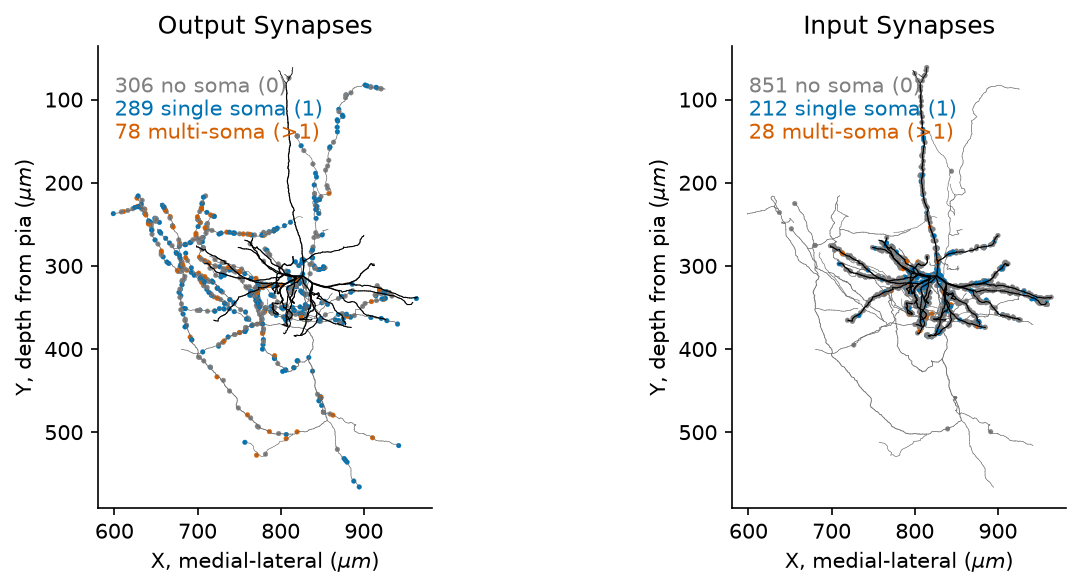

In [19]:
# Figure 3: Skeleton with inputs and outputs, filtered by 'known' connections

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

point_size = 5
soma_palette = {
    "no soma (0)":     "grey",
    "single soma (1)": "#0072B2",   # blue
    "multi-soma (>1)": "#D55E00",   # vermillion — the category that corrupts analysis
}
soma_order = ["no soma (0)", "single soma (1)", "multi-soma (>1)"]

for i in range(2):
    osy.plot.plot_morphology_2d(cell_um,
                                projection="xy",
                                color="compartment",
                                palette={osy.SWC_DENDRITE: "black", osy.SWC_AXON: "dimgrey"},
                                linewidth="radius",
                                linewidth_norm=(100, 1000),
                                widths=(0.25, 2),
                                ax=ax[i])
# Output synapses
sns.scatterplot(data=output_df, x="syn_x_um", y="syn_y_um", legend=False,
                s=point_size, hue="soma_class", palette=soma_palette, hue_order=soma_order,
                ax=ax[0], edgecolor=None)

# Input synapses
sns.scatterplot(data=input_df, x="syn_x_um", y="syn_y_um", legend=False,
                s=point_size, hue="soma_class", palette=soma_palette, hue_order=soma_order,
                ax=ax[1], edgecolor=None)

for j, label in enumerate(soma_order):
    n = (output_df["soma_class"] == label).sum()
    ax[0].text(0.05, 0.9 - 0.05 * j, f"{n} {label}",
            color=soma_palette[label], transform=ax[0].transAxes)
for j, label in enumerate(soma_order):
    n = (input_df["soma_class"] == label).sum()
    ax[1].text(0.05, 0.9 - 0.05 * j, f"{n} {label}",
            color=soma_palette[label], transform=ax[1].transAxes)

ax[0].set(title="Output Synapses", xlabel=r'X, medial-lateral ($\mu m$)', ylabel=r'Y, depth from pia ($\mu m$)')
ax[1].set(title="Input Synapses", xlabel=r'X, medial-lateral ($\mu m$)', ylabel=r'Y, depth from pia ($\mu m$)')
sns.despine()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h4> Which partners do we actually know? </h4>
<p>We can confidently assign synaptic partners <b>only when <code>n_soma==1</code></b>.
<p>There is an asymmetry here that is worth dwelling on: we know about 40% <code>289/(289+306+78)</code> of postsynaptic partners to this neuron, and 20% <code>212/(212+28+851)</code> presynaptic partners. These reflect different categories of unknowns.
<p>For connectivity analysis, we generally take the conservative approach and drop all multi-soma objects as 'unknowns'.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h4> Explicit proofreading status </h4>
<p>In addition, we keep a list of which cells in the dataset have undergone <b>comprehensive proofreading</b> such that their axon outputs are trustworthy. Our example cell is proofread, which we can see with:

</div>

In [20]:
client.materialize.tables.proofreading_status_and_strategy(pt_root_id=root_id).query(
    select_columns=['pt_root_id','status_dendrite','status_axon','strategy_dendrite','strategy_axon']
)

,pt_supervoxel_id,pt_root_id,status_dendrite,status_axon,strategy_dendrite,strategy_axon
0,92829912045986361,864691132534315610,True,True,dendrite_extended,axon_fully_extended


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>We add proofreading status of the input axon as an explicit category

</div>

In [21]:
prf_axon_ids = set(
    client.materialize.tables.proofreading_status_and_strategy(status_axon=True)
    .query(select_columns=["pt_root_id"])["pt_root_id"]
)

# declared before it can be assigned into a Categorical
input_df["partner_class"] = input_df["soma_class"].cat.add_categories("axon proofread")
input_df.loc[input_df["pre_pt_root_id"].isin(prf_axon_ids), "partner_class"] = "axon proofread"

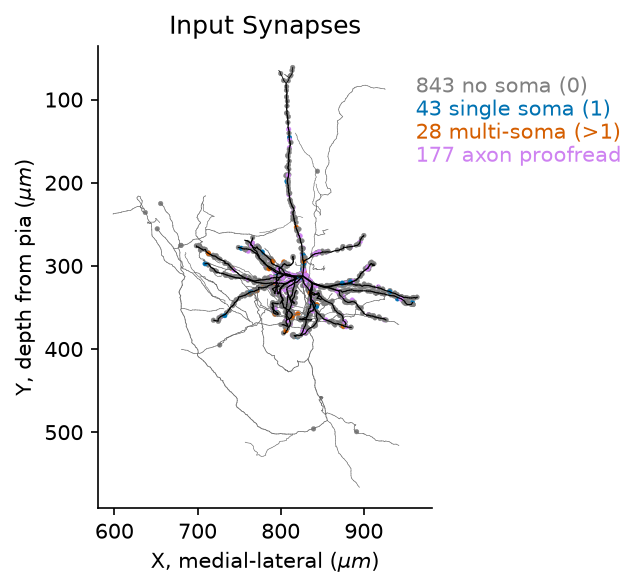

In [22]:
# Figure 4: Skeleton with inputs and outputs, filtered by 'known' connections

fig, ax = plt.subplots(1, 1, figsize=(5, 4), dpi=150)

point_size = 5
partner_palette = {
    "no soma (0)":     "grey",
    "single soma (1)": "#0072B2",   # blue
    "axon proofread":  "#CE82F1",   # lavender
    "multi-soma (>1)": "#D55E00",   # vermillion — the category that corrupts analysis
}
partner_order = ["no soma (0)", "single soma (1)", "multi-soma (>1)", "axon proofread"]


osy.plot.plot_morphology_2d(cell_um,
                            projection="xy",
                            color="compartment",
                            palette={osy.SWC_DENDRITE: "black", osy.SWC_AXON: "dimgrey"},
                            linewidth="radius",
                            linewidth_norm=(100, 1000),
                            widths=(0.25, 2),
                            ax=ax)


# Input synapses
sns.scatterplot(data=input_df, x="syn_x_um", y="syn_y_um", legend=False,
                s=point_size, hue="partner_class", palette=partner_palette, hue_order=soma_order,
                ax=ax, edgecolor=None)


for j, label in enumerate(partner_order):
    n = (input_df["partner_class"] == label).sum()
    ax.text(.95, 0.9 - 0.05 * j, f"{n} {label}",
            color=partner_palette[label], transform=ax.transAxes)

ax.set(title="Input Synapses", xlabel=r'X, medial-lateral ($\mu m$)', ylabel=r'Y, depth from pia ($\mu m$)')
sns.despine()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>This is a smaller 10% <code>177/(177+43+28+843)</code> of inputs that we trust.
<p>Every one of those grey input points is a synapse that (probably) genuinely happened. What's missing is the partner's identity, and beyond that, how many other synapses that partner made. So inputs will tell you what lands on this cell and where; only the proofread subset supports "how strongly is A connected to B" or any connection-probability statement.
<p>This is the critical point when framing analysis: what is your denominator for comparison? Is it all neurons? All single-soma neurons? All proofread neurons? The right answer depends on your question. Module 2 this afternoon will restrict to proofread cohorts, which is a safe but conservative framing.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Morphological cell types </h2>
<img src="../workshops/img/neuron_rogues_gallery.png" width="1000">
<p>Identifying the putative ‘cell type’ from the EM morphology is a process that involves both manual and automatic classifications. Subsets of the dataset have been manually classified by anatomists at the Allen Institute, and these ground truth labels used to train and refine different automated ‘feature classifiers’ over time.
<p>The diversity of manual and automated cell type classifications available in the dataset reflect the fact that definitions of ‘cell types’ in the dataset is an active area of research and must be contextualized against the purpose and resolution of the cell-typing being performed.
<p>Two of the most predictive features for broad cell type are:
<ul>
<li>Soma location (in units of depth from pial surface). This captures cortical layer diversity
<li>Soma size (in units of volume). This is a strong proxy of many types of cell morphological diversity
</ul>
<p>For this, we will grab the soma information like we did before, but explicitly include <code>volume</code>. This is a measurement of the <b>nucleus volume in cubic microns</b>:

</div>

In [23]:
# CAVEquery the nucleus lookup table
soma_df= client.materialize.tables.nucleus_detection_v0().query(
    select_columns = ['id','pt_root_id','pt_position','volume'],
    desired_resolution = [1,1,1],
).rename(columns={"volume": "nucleus_volume"})

# Data cleaning: annotate the duplicates on `pt_root_id`. n_soma>1 are 'multi-soma' objects make interpretation difficult.
soma_counts = (
    soma_df.groupby("pt_root_id")["id"].nunique().rename("n_soma").reset_index()
)

# desired_resolution=[1,1,1] means the positions come back in nanometres, so the same
# transform we used on the synapses applies here unchanged — depth in microns below pia.
soma_df["depth_um"] = tform.apply_dataframe("pt_position", soma_df, projection="y")

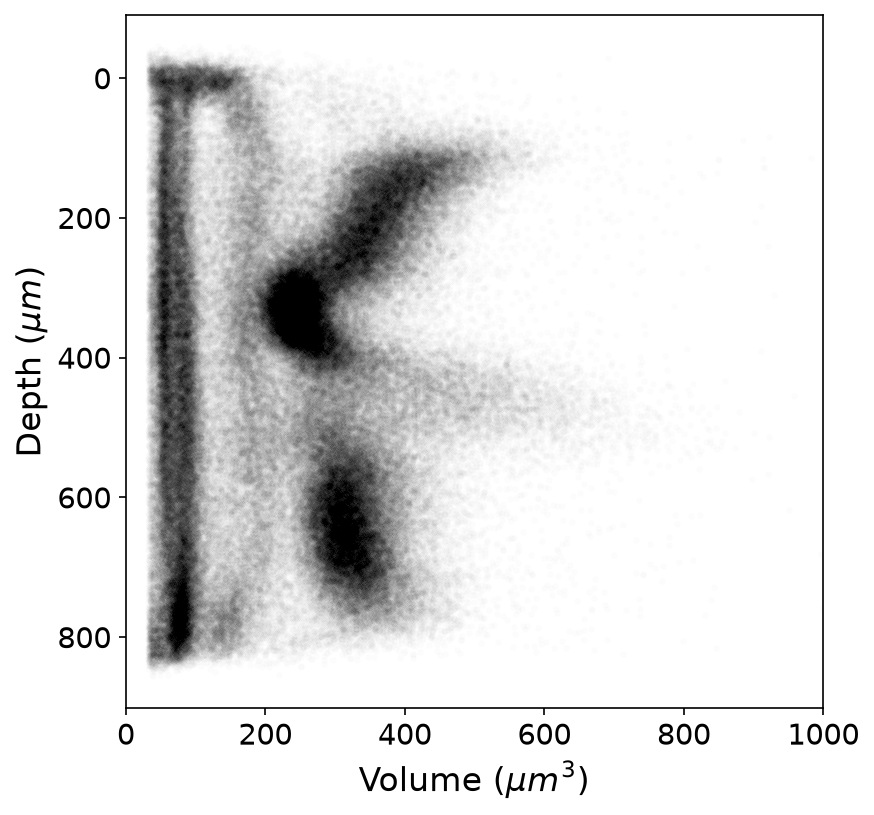

In [24]:
# Figure 5: Spatial Organization of Cell Nuclei in the tissue

# Plot cell volume by depth
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
ax.tick_params(labelsize=14)
sns.scatterplot(
    data=soma_df,
    x="nucleus_volume",
    y="depth_um",
    s=8,          # marker size. `size=` would ask seaborn for a size *variable*
    edgecolor=None,
    alpha=0.01,
    color="k",
    ax=ax,
    legend=False,
)
ax.invert_yaxis()
ax.set_xlabel(r"Volume ($\mu m^3$)", fontsize=16)
ax.set_ylabel(r"Depth ($\mu m$)", fontsize=16)
ax.set_xlim(0, 1000)
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Using the automated cell types </h3>
<p>Many of these automated cell type definitions were established and refined for the <a href="https://www.microns-explorer.org/">MICrONS Dataset</a> including:
<ul>
    <li> Perisomatic cell features <a href=https://www.nature.com/articles/s41586-024-07765-7>(Elabbady et al.)</a> </li>
    <li> Morphology and connectivity features <a href=https://www.nature.com/articles/s41586-024-07780-8>(Schneider-Mizell et al.)</a> </li>
</ul>
<p>The process of applying these labels to the V1DD dataset is ongoing, but we will use cell typing from the <code>cell_type_multifeature_v1</code> table which labels cell types using soma, nucleus, dendrite, and spine features.
<p>Excitatory neurons are labeled by projection category (IT, ET, NP, CT, and SP for subplate).
<p>Inhibitory neurons follow labels based on targeting such as ITC (inhibitory targeting), STC (sparsely targeting), PTC (perisomatic targeting), and DTC (dendrite targeting), but might align more with molecular class than exact targeting for a given neuron, particularly among ITC/VIP cells.
<p><i>Note:</i> Cells here without a label are null and will disappear. These are either non-neuronal cells or potential neurons with <code>n_soma!=1</code>

</div>

In [25]:
cell_type_df = client.materialize.tables.cell_type_multifeature_v1().query(
    desired_resolution=[1, 1, 1], 
    split_positions=True,
).rename(columns={"classification_system": "cell_type_coarse",})


# add to our soma_df on nucleus id
soma_cell_type_df = soma_df.merge(cell_type_df[['id','cell_type','cell_type_coarse']], on='id', how='left')

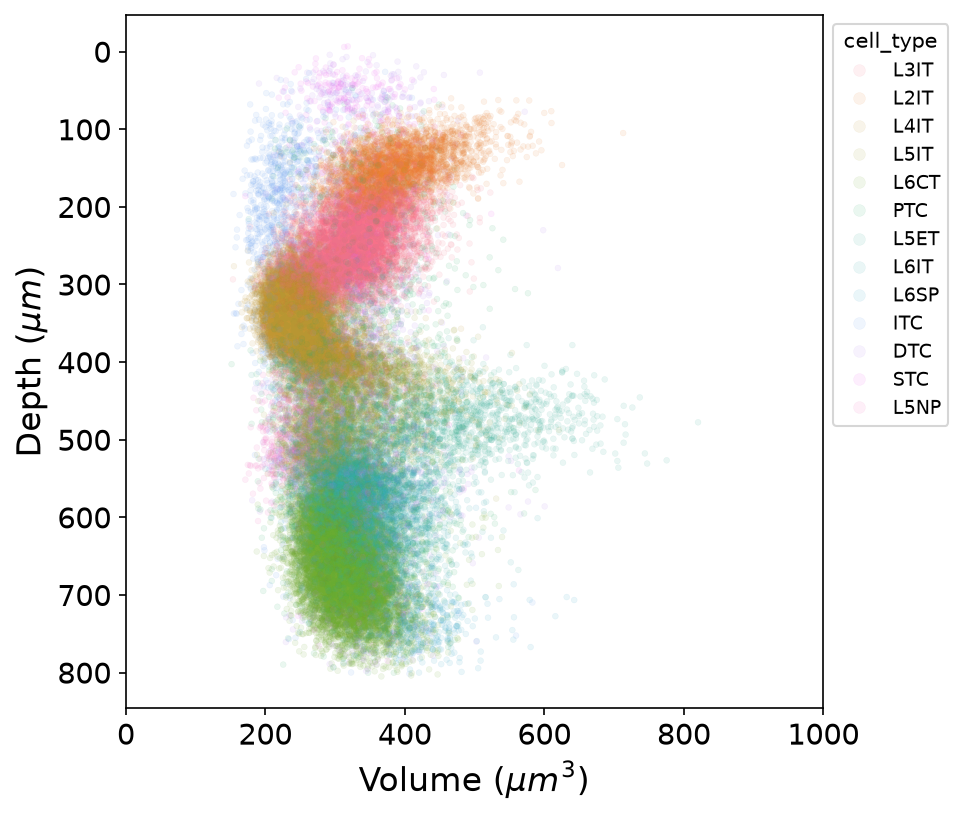

In [26]:
# Figure 6: The same cells, coloured by automated cell type

fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
ax.tick_params(labelsize=14)

# Color hue by cell_type 
sns.scatterplot(
    data=soma_cell_type_df,
    x="nucleus_volume",
    y="depth_um",
    s=8,
    edgecolor=None,
    alpha=0.1,
    color="k",
    ax=ax,
    legend=True,
    hue="cell_type",
)
ax.invert_yaxis()
ax.set_xlabel(r"Volume ($\mu m^3$)", fontsize=16)
ax.set_ylabel(r"Depth ($\mu m$)", fontsize=16)
ax.set_xlim(0, 1000)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), fontsize=9, markerscale=2)
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Exercise 4: Separate inhibitory and excitatory classes</b>
<p>Separate this plot by inhibitory and excitatory classes (hint: <code>cell_type_coarse</code>), as two subplots

</div>

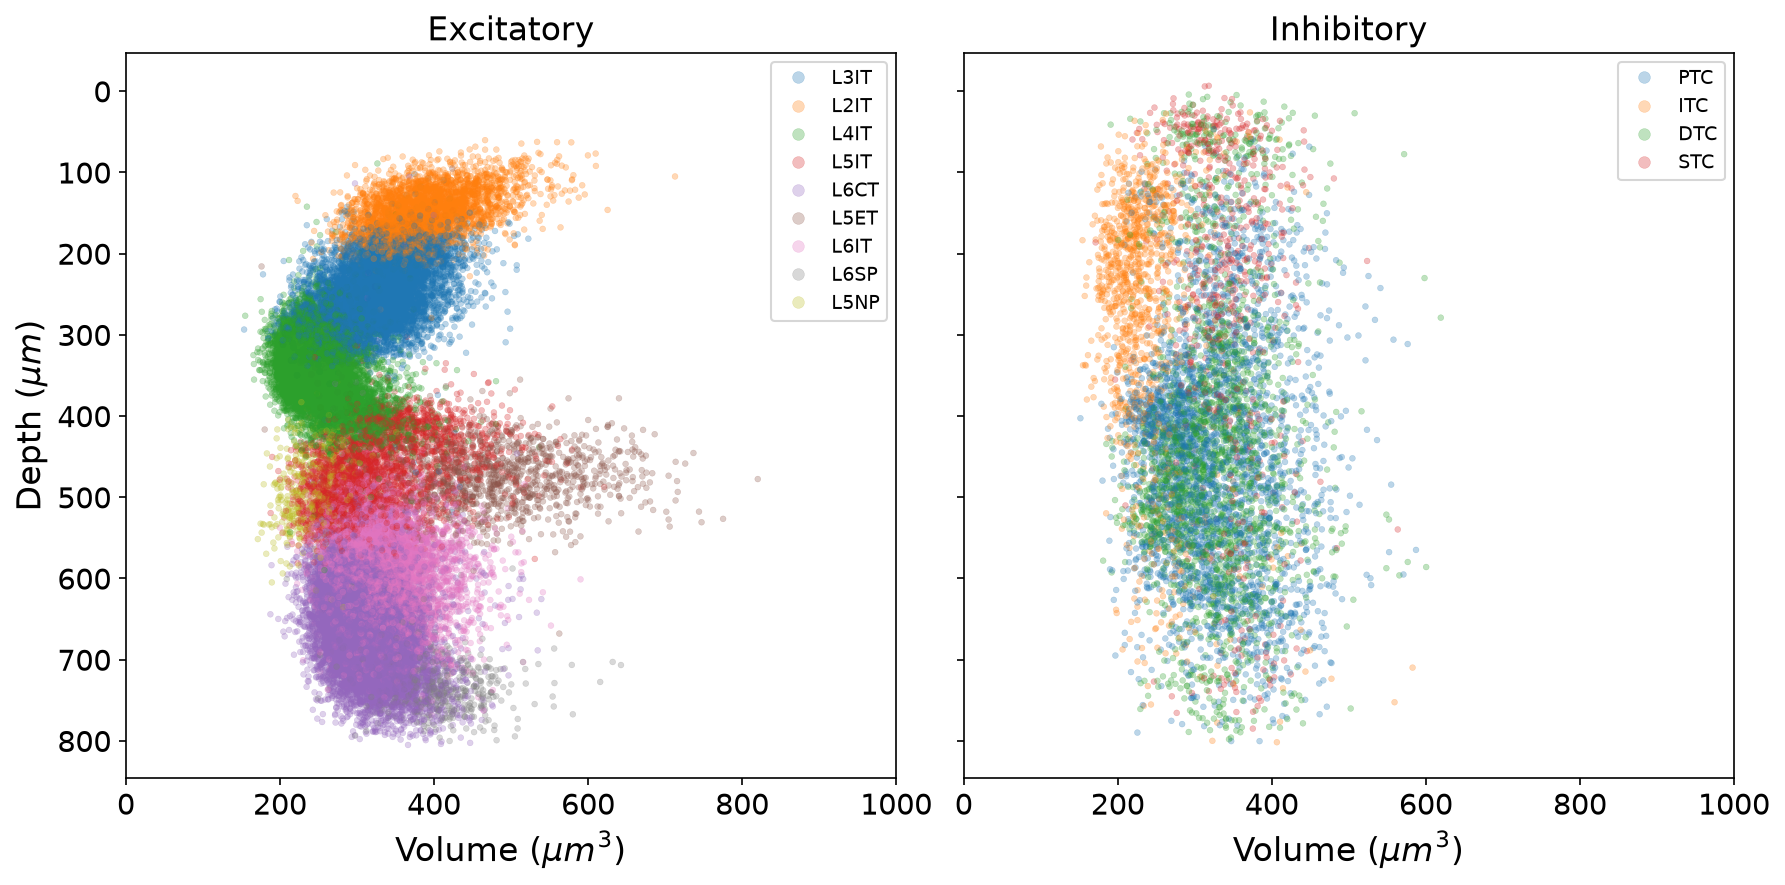

In [27]:
# Figure 7: Excitatory and inhibitory cells separated

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=150, sharex=True, sharey=True)

# 'excitatory' and 'inhibitory' are the coarse labels; cells with no label are None and drop out of the query
for ax, coarse, title in zip(axes, ["excitatory", "inhibitory"], ["Excitatory", "Inhibitory"]):
    sns.scatterplot(
        data=soma_cell_type_df.query("cell_type_coarse == @coarse"),
        x="nucleus_volume",
        y="depth_um",
        s=8,
        edgecolor=None,
        alpha=0.3,
        hue="cell_type",
        ax=ax,
    )
    ax.set_title(title, fontsize=16)
    ax.set_xlim(0, 1000)
    ax.set_xlabel(r"Volume ($\mu m^3$)", fontsize=16)
    ax.tick_params(labelsize=14)
    ax.legend(fontsize=9, markerscale=2)

# sharey=True, so inverting one axis inverts both
axes[0].invert_yaxis()
axes[0].set_ylabel(r"Depth ($\mu m$)", fontsize=16)


plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Gallery of cell types </h3>
<p>Depth and soma volume separate the broad classes, but they do not show you what a cell type <i>is</i>. The clearest way to see that is to put the morphologies side by side and let the shapes make the argument.

</div>

In [28]:
%%time

gallery_ids = {
    "L2-IT":      864691132546426513,   # excitatory, superficial, apical dendrite to pia
    "L5-ET":      864691132596046903,   # excitatory, deep, thick apical trunk
    "Martinotti": 864691132562471396,   # inhibitory, ascending axon arborising in L1
    "Basket":     864691132586288610,   # inhibitory, dense perisomatic axon near the soma
    "Bipolar":    864691132544823185,   # inhibitory, narrow bitufted arbor (VIP/ITC)
}

gallery_dict = {}

for (label, gallery_root_id) in gallery_ids.items():

    gallery_dict[label] = osy.load_cell_from_client(
            root_id=gallery_root_id,
            client=client,
        ).transform(tform.apply)


CPU times: user 35.2 s, sys: 679 ms, total: 35.8 s
Wall time: 1min


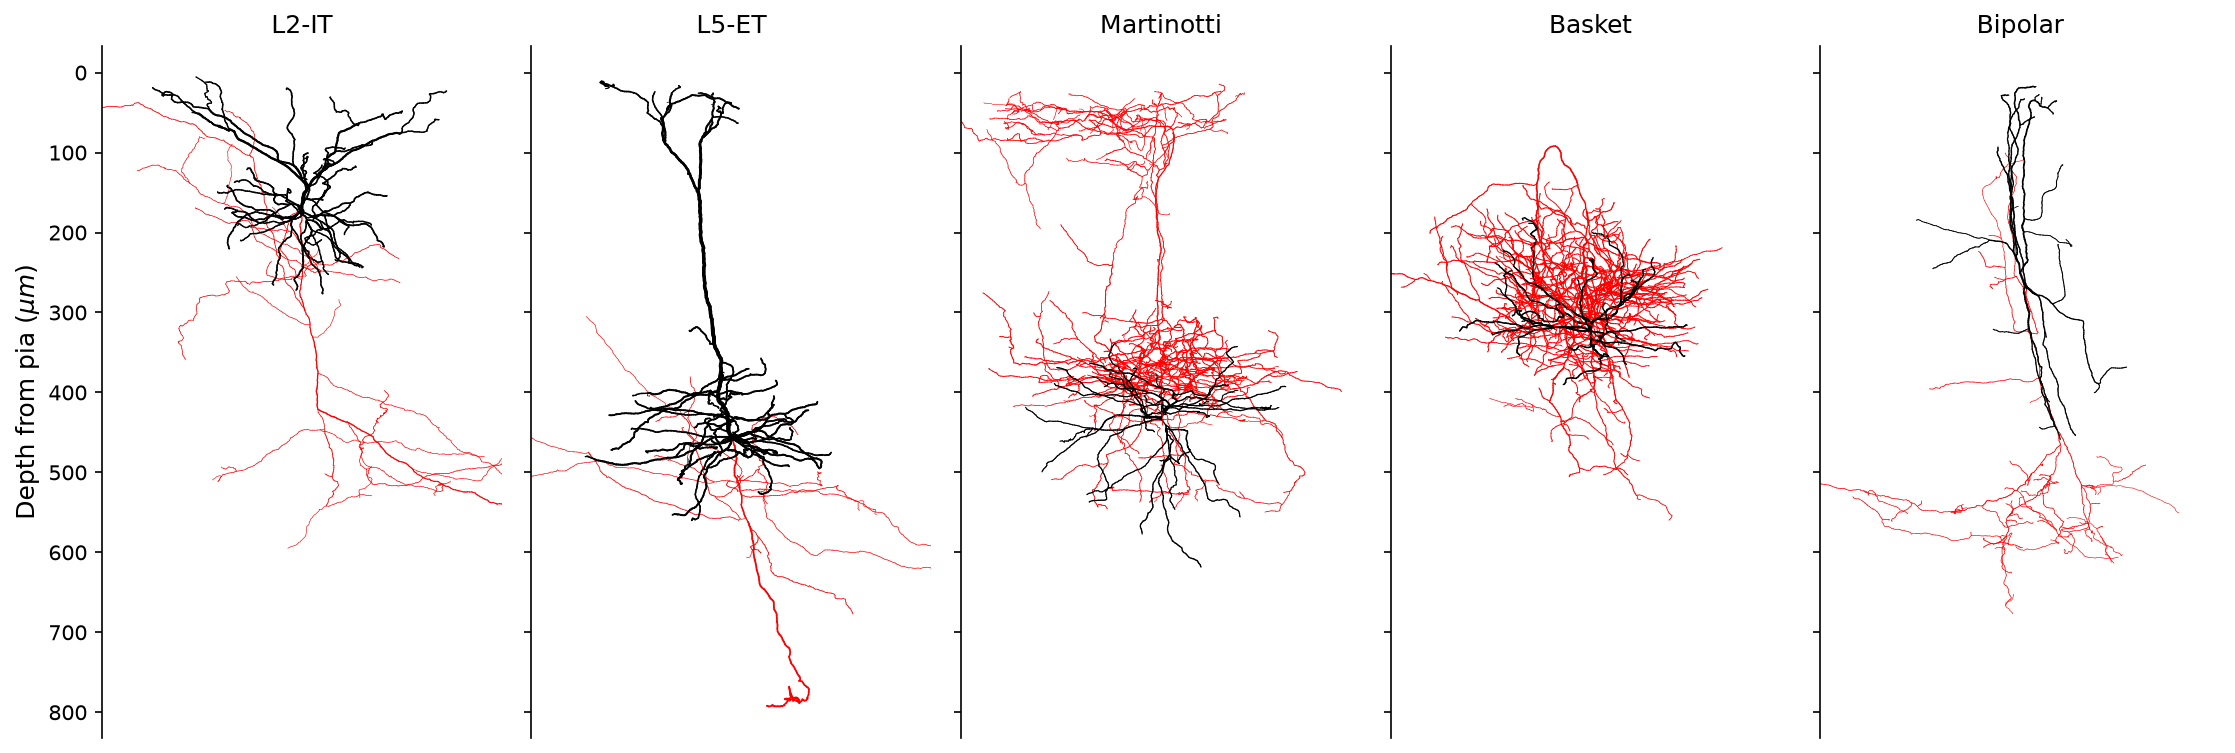

In [29]:
# Figure 8: A gallery of morphological cell types

# The same horizontal span in every panel. Depth is shared and left in true pial coordinates
HALF_WIDTH_UM = 250

fig, axes = plt.subplots(1, 5, figsize=(15, 6), dpi=150, sharey=True)

for ax, (label, gallery_root_id) in zip(axes, gallery_ids.items()):
    if gallery_root_id is None:
        ax.set_title(f"{label}\n(root_id needed)", fontsize=10, color="grey")
        ax.set_axis_off()
        continue

    gallery_cell = gallery_dict[label]

    osy.plot.plot_morphology_2d(
        gallery_cell,
        projection="xy",
        color="compartment",
        palette={osy.SWC_DENDRITE: "black", osy.SWC_AXON: "red"},
        linewidth="radius",
        linewidth_norm=(100, 1000),
        widths=(0.25, 2),
        ax=ax,
    )

    # Centre each panel on its own soma so the arbors are comparable side by side
    soma_x = gallery_cell.s.root_location[0]
    ax.set_xlim(soma_x - HALF_WIDTH_UM, soma_x + HALF_WIDTH_UM)
    ax.set_title(label, fontsize=12)
    ax.set_xticks([])
    ax.set_xlabel("")

axes[0].set_ylabel(r"Depth from pia ($\mu m$)", fontsize=12)
sns.despine(bottom=True)
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Interactive session in neuroglancer </h2>
<p>Navigation Instructions in the <a href="https://allenswdb.github.io/anatomy/microns-em/em-neuroglancer.html">DataBook: Neuroglancer</a>.
<p><b>V1DD Neuroglancer Explorer</b>:
<p> With Cell Type segment properties : <a href="https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/6528485848776704">https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/6528485848776704</a>
<p>You will be prompted for a google login. Use the same account you used to authenticate your CAVE token
<p><b>Bonus Neuroglancer links</b>:
<p> Proofreading Status Segment Properties: <a href="https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5293734357893120">https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5293734357893120</a> 
<p> Cell type filtered by axon status: <a href="https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5848621518422016">https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5848621518422016</a> 
<p> Synapses with spine/shaft/soma labels (can be slow to load): <a href="https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5867245166133248">https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5867245166133248</a>

</div>

<hr style="height: 4px; background: #000; border: none;">

<h2 align="center">Coffee break</h2>

<p align="center">After the break we pick up a different question &mdash; whether the <i>kind</i> of cell a neuron targets depends on <i>where</i> along its axon the synapse is.</p>

<hr style="height: 4px; background: #000; border: none;">

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> The spatial organization of connectivity </h2>
<p>One organizing principles of nervous systems is that neurons use their spatial relationships to build connectivity networks that produce useful functional activity.
<p>Spatial or temporal patterning of excitation and inhibition can create different kinds of activity. For example, excitation followed by inhibition can sharpen responses, shown nicely in <a href="https://pubmed.ncbi.nlm.nih.gov/14647382/">Wehr and Zador 2003</a> which looked at spikes in auditory cortex while mapping excitatory (green) and inhibitory (red) currents. The individual currents can sum to predict (in yellow) the actual measured voltage response (in navy blue).
<img src="../workshops/img/e_i_offset.png" width="500">
<p>Spatial offsets can create novel circuit computations such as orientation selectivity (e.g. <a href="https://www.nature.com/articles/s41586-020-2894-4">Rossi, Carandini, and Harris 2020</a>), by having receptive fields for excitation precede that for inhibition only in a prefered direction. Biases in connectivity as a function of space are one way to achieve this sort of organization. This has been well-mapped in neurons of the Drosophila visual system, and a similar result has been found for certain L2/3 pyramidal cells by the Carandini and Harris labs.
<img src="../workshops/img/spatial_offset_rossi.png" width="500">
<h3> How is connectivity organized across an axon? </h3>
<p>Dense connectomics data is well suited to exploring the relationship between cell types, spatial structure, and synaptic connectivity by giving detailed access to neuronal morphology and connectivity across hundreds or even thousands of synapses.
<p>Here, we will look for evidence of spatial structure in how pyramidal cells distribute their local output across inhibitory and excitatory neurons. This analysis will put together both skeleton topology and cell type information in order to ask if the type of neurons a pyramidal cell targets depends on the location along the pyramidal cell axon.
<p>This analysis is inspired by a paper from medial entorhinal cortex, a part of the hippocampus, in <a href="https://www.nature.com/articles/nature24005">Schmidt et al., Nature 2017</a>.
<p>This work found an offset between where an excitatory neuron synapsed onto inhibitory neurons (black lines) versus excitatory neurons (magenta lines):
<img src="../workshops/img/axon_sorting.png" width="500">
<p>We are going to do a similar analysis for pyramidal cells in the V1dd dataset here.

</div>

In [30]:
# To start with, let's build a list of all of the proofread cells and all clearly cell typed cells.

pf_df = client.materialize.tables.proofreading_status_and_strategy(
    status_axon=True
).query(split_positions=True)

ct_df = client.materialize.tables.cell_type_multifeature_v1().get_all(
    split_positions=True, desired_resolution=[1, 1, 1]
)
ct_df = ct_df.drop_duplicates(subset="pt_root_id", keep=False)


# Merge these two into one table and clean the table

pf_ct_df = pf_df.query("status_axon == True").merge(
    ct_df[["id", "pt_root_id", "classification_system", "cell_type"]].rename(
        columns={"id": "cell_id"}
    ),
    on="pt_root_id",
)[
    [
        "pt_root_id",
        "cell_id",
        "classification_system",
        "cell_type",
        "pt_position_x",
        "pt_position_y",
        "pt_position_z",
    ]
]

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> A second example cell </h3>
<p>The rest of the module works from a <i>different</i> neuron. The cell we have used so far was chosen to show inputs and outputs together; for the spatial analysis below we want one whose axon is fully proofread, so that the synapses we count along it are the ones it actually makes.
<p>Note that <code>root_id</code> and <code>cell</code> are reassigned in the next few cells. If you come back and re-run an earlier figure, it will use this new neuron.

</div>

In [31]:
root_id = pf_ct_df.query('cell_type == "L3IT"').pt_root_id.iloc[64]

cell = osy.load_cell_from_client(
    root_id=root_id,
    client=client,
    synapses=True,
    include_partner_root_id=True,
)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Get an idea of what the cell looks like before doing analysis </h3>

</div>

<Axes: >

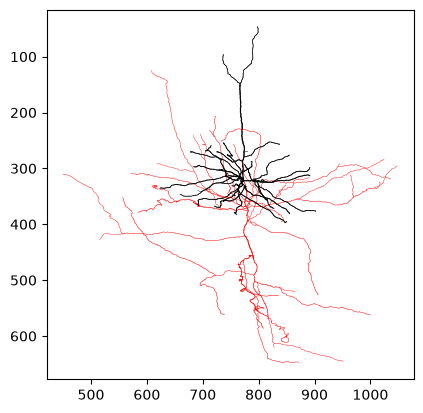

In [32]:
osy.plot.plot_morphology_2d(
    cell.transform(v1dd_ds.transform("nm").apply),
    color="compartment",
    palette={osy.SWC_DENDRITE: "black", osy.SWC_AXON: "red"},
    linewidth="radius",
    linewidth_norm=(100, 1000),
    widths=(0.25, 2),
    projection="xy",
)

In [33]:
# For clarity, let's make sure to only take output synapses on the axon of the cell. This avoids any false detections or small merges elsewhere on the cell.

cell_axon = cell.s.apply_mask(cell.skeleton.df["compartment"] == osy.SWC_AXON)
pre_syn_anno = cell_axon.annotations.pre_syn

# We want to make a normal Pandas dataframe off of the more dynamically generated data in the annotation.

pre_syn_df = pre_syn_anno.df

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> What did that mask do? </h3>
<p>Ossify masks restrict the object to only part of the cell. Because Ossify links the skeleton and the synapse annotations, masking on the skeleton also shows only those annotations associated with the skeleton points of the axon.
<h4> Why did we just do that? </h4>
<p>Synapse detection is good, but even well-proofread cells can have errors that can arise from a number of situations. For example,
<ul>
<li>Errors in synapse detection or partner assignment add a presynaptic synapse to a dendrite
<li>A small axonal bouton is merged into a dendrite and was not noticed on proofreading.
<li>A real biological junction is found on a dendrite and incorrectly identified as a synapse.
</ul>
<p>By masking out the dendrite, we can avoid some of these some of these errors.

</div>

<Axes: >

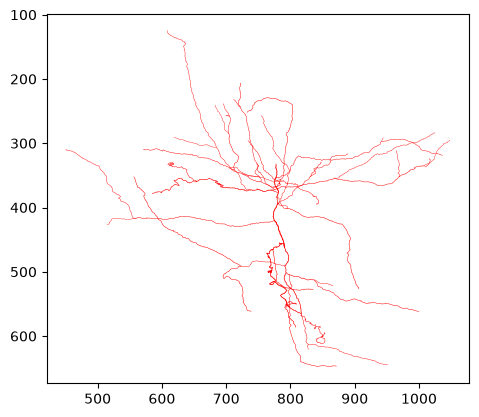

In [34]:
# Confirm that the masking does what we expected:

osy.plot.plot_morphology_2d(
    cell_axon.transform(v1dd_ds.transform("nm").apply),
    color="compartment",
    palette={osy.SWC_DENDRITE: "black", osy.SWC_AXON: "red"},
    linewidth="radius",
    linewidth_norm=(100, 1000),
    widths=(0.25, 2),
    projection="xy",
)

In [35]:
pre_syn_df.head()

,created,deleted,pre_pt_position_x,pre_pt_position_y,pre_pt_position_z,post_pt_position_x,post_pt_position_y,post_pt_position_z,ctr_pt_position_x,ctr_pt_position_y,ctr_pt_position_z,size,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_l2_id
id,,,,,,,,,,,,,,,,,
359131268,2021-11-18 22:05:11.388179+00:00,NaT,745561,680629,332370,746027,680231,332685,745794.0,680610.0,332325.0,1995.0,90649718128113752,864691132669678865,90649718128119755,864691132659029623,162707312165781801
335356083,2021-11-18 22:06:07.045240+00:00,NaT,736850,561649,299610,737258,561649,299700,736957.0,561639.0,299565.0,710.0,90364944482659064,864691132669678865,90435313226853131,864691132611395389,162422538519971307
297061600,2021-11-18 22:07:36.311454+00:00,NaT,667738,604707,346680,667272,604552,347085,667418.0,604698.0,346860.0,619.0,88466225541214435,864691132669678865,88395788077570707,864691132001965873,160523819579082288
213480645,2021-11-18 22:07:58.670416+00:00,NaT,557439,752273,248310,557691,752632,248265,557653.0,752370.0,248175.0,1334.0,85303686167185844,864691132669678865,85303686167183606,864691130125286788,157361280204670852
542148571,2021-11-18 22:07:58.670416+00:00,NaT,1024203,631974,297360,1024455,632139,296910,1024475.0,631993.0,297090.0,1465.0,98529642952541709,864691132669678865,98529711672029241,864691132686920900,170587236989929143


In [36]:
pre_syn_df = pre_syn_df.merge(
    ct_df[["pt_root_id", "classification_system", "cell_type"]],
    how="left",
    left_on="post_pt_root_id",
    right_on="pt_root_id",
).rename(
    columns={
        "classification_system": "synapse_target_class"
    }  # Rename the column for clarity
)

In [37]:
pre_syn_df.head()

,created,deleted,pre_pt_position_x,pre_pt_position_y,pre_pt_position_z,post_pt_position_x,post_pt_position_y,post_pt_position_z,ctr_pt_position_x,ctr_pt_position_y,ctr_pt_position_z,size,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_l2_id,pt_root_id,synapse_target_class,cell_type
0,2021-11-18 22:05:11.388179+00:00,NaT,745561,680629,332370,746027,680231,332685,745794.0,680610.0,332325.0,1995.0,90649718128113752,864691132669678865,90649718128119755,864691132659029623,162707312165781801,864691132659029623,inhibitory,DTC
1,2021-11-18 22:06:07.045240+00:00,NaT,736850,561649,299610,737258,561649,299700,736957.0,561639.0,299565.0,710.0,90364944482659064,864691132669678865,90435313226853131,864691132611395389,162422538519971307,864691132611395389,excitatory,L6IT
2,2021-11-18 22:07:36.311454+00:00,NaT,667738,604707,346680,667272,604552,347085,667418.0,604698.0,346860.0,619.0,88466225541214435,864691132669678865,88395788077570707,864691132001965873,160523819579082288,<NA>,<NA>,<NA>
3,2021-11-18 22:07:58.670416+00:00,NaT,557439,752273,248310,557691,752632,248265,557653.0,752370.0,248175.0,1334.0,85303686167185844,864691132669678865,85303686167183606,864691130125286788,157361280204670852,<NA>,<NA>,<NA>
4,2021-11-18 22:07:58.670416+00:00,NaT,1024203,631974,297360,1024455,632139,296910,1024475.0,631993.0,297090.0,1465.0,98529642952541709,864691132669678865,98529711672029241,864691132686920900,170587236989929143,864691132686920900,inhibitory,PTC


In [38]:
# How many synapses actually have target classifications?

pre_syn_df.value_counts("synapse_target_class")

synapse_target_class
excitatory    144
inhibitory    123
Name: count, dtype: int64

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Kinds of Distances </h2>
<p>There are different ways of measuring the distance between two points in the EM datasets. Let's consider the distance between a cell body and a synapse (red dot):
<img src="../workshops/img/neuron_cartoon_base.png" height="500">

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Euclidean </h3>
<p>The direct line distance between the two points is the Euclidean distance. It treats all axes the same, which may or may not work well in cortex.
<img src="../workshops/img/neuron_cartoon_euclidean.png" height="500">

</div>

In [39]:
# Let's check the units

cell.s.root_location

# The high numbers indicate that the location in nm, as is default for skeletons

array([769792., 647417., 267165.])

In [40]:
euc_distance_um = (
    np.linalg.norm(
        pre_syn_anno.vertices - cell.s.root_location,
        axis=1,
    )
) / 1000.0  # Convert from nm to microns by dividing by 1000

pre_syn_df["dist_to_root_euc"] = euc_distance_um

<Axes: xlabel='dist_to_root_euc', ylabel='Count'>

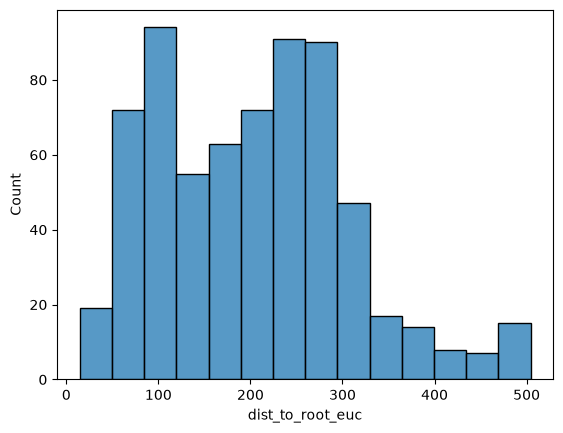

In [41]:
sns.histplot(x="dist_to_root_euc", data=pre_syn_df)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Radial </h3>
<p>Another way to measure locations is so-called cylindrical coordinates, where you distinguish a depth axis from a radial distance. Here, we typically use the y-axis for cortical depth, so this radial distance is specifically within the x-z plane. This approch treats radial distance as a different measure from distance along depth.
<p>This distance is also called <code>tangential</code> or <code>lateral</code>.
<img src="../workshops/img/neuron_cartoon_cylin.png" height="500">

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h4> Streamline-radial distance (the better choice) </h4>
<p>In practice, it turns out that cells do not follow a straight line from pia to white matter. At a given location, apical dendrites and descending axons turn out to follow a "streamline" that is is specific to that location. When measuring radial distances relative to a cell body at very different layers, it is useful to use the <code>radial_distance</code> function in <code>standard_transform</code>, which takes this streamline into account.
<img src="../workshops/img/steamline_correction_cartoon.png" height="500">
<p>Note: If you want to straighten a whole cell according to its streamline, you can do that via: <code>cell_straightened = cell.transform(v1dd_ds.streamline('nm').transformer(cell.s.root_location))</code>

</div>

In [42]:
radial_distance_um = v1dd_ds.streamline("nm").radial_distance(
    cell.s.root_location,
    pre_syn_anno.vertices,
)

pre_syn_df["dist_to_root_radial"] = radial_distance_um

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Geodesic Distance </h3>
<p>Geodesic distance refers to the shortest path along a surface or graph, and is the same as the <b>path length</b> plot in the Schmidt paper. Here, we use it to refer to the distance along a neuronal skeleton. Since the skeleton is a tree (i.e. there are no loops), the geodesic distance is the same as the one path between the cell body and the point in question (here, the synapse).
<p>This distance called by other names, including <code>topological</code> or <code>path length</code>.
<img src="../workshops/img/neuron_cartoon_geod.png" height="500">

</div>

In [43]:
# The skeleton is rooted at the cell body. We can simply use the distance_to_root function to get the geodesic distance
# along the skeleton from vertices in an annotation to the root vertex. There is also a pre_syn_anno.distance_between
# to compute a distance between vertices.

pre_syn_df["dist_to_root_geo"] = pre_syn_anno.distance_to_root() / 1000

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Questions:</b>
<p>Before running the next cell, think about the relationship between these distances.
<ol>
<li>Which distance should be the shortest? The longest?
<li>What limitation does geodesic distance have that Euclidean and radial distance does not have?
</ol>

</div>

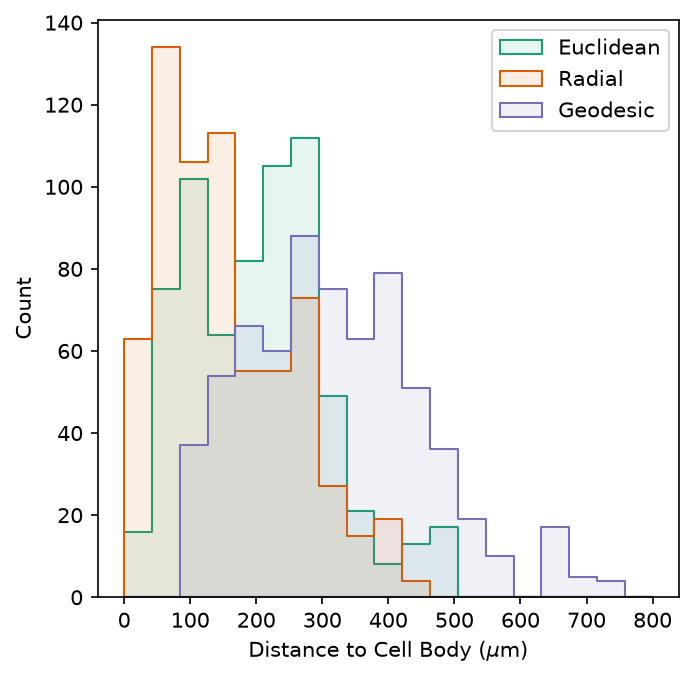

In [44]:
bins = np.linspace(0, 800, 20)

fig, ax = plt.subplots(figsize=(5, 5), dpi=150)

sns.histplot(
    pre_syn_df["dist_to_root_euc"],
    color=sns.color_palette("Dark2")[0],
    element="step",
    bins=bins,
    alpha=0.1,
)

sns.histplot(
    pre_syn_df["dist_to_root_radial"],
    color=sns.color_palette("Dark2")[1],
    element="step",
    bins=bins,
    alpha=0.1,
)

sns.histplot(
    pre_syn_df["dist_to_root_geo"],
    color=sns.color_palette("Dark2")[2],
    element="step",
    bins=bins,
    alpha=0.1,
)

ax.set_xlabel(r"Distance to Cell Body ($\mu$m)")
ax.legend(["Euclidean", "Radial", "Geodesic"])

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Question:</b>
<p>Does the relative distributions of these curves make sense?

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h4> How much axon is there? </h4>
<p>The above just looked at synapses. If you want to know about the same distribution for axon itself, we can use similar functions on the skeleton to get this information: 1) <code>skeleton.distance_to_root</code> gives distance to root for each vertex (in nm by default) 2) <code>skeleton.half_edge_length</code> gives the amount of branch length associated with each skeleton vertex.

</div>

In [45]:
dist_axon_um = cell_axon.skeleton.distance_to_root() / 1_000
len_axon_um = cell_axon.skeleton.half_edge_length / 1_000

Text(0, 0.5, 'Microns of axon')

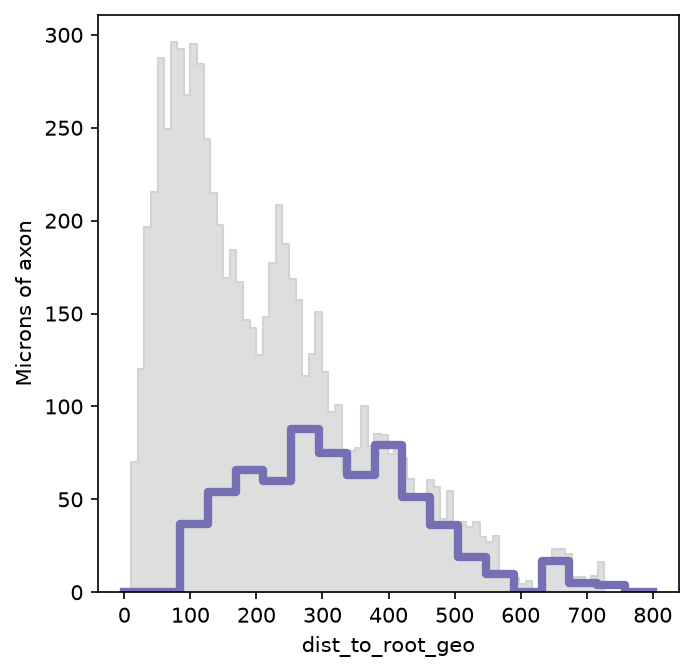

In [46]:
# For a quick plot, we can just treat this as a length-weighted histogram of skeleton vertex distances.

fig, ax = plt.subplots(figsize=(5, 5), dpi=150)

sns.histplot(
    x=dist_axon_um,
    weights=len_axon_um,
    binwidth=10,
    color="lightgray",
    element="step",
    ax=ax,
)

sns.histplot(
    pre_syn_df["dist_to_root_geo"],
    color=sns.color_palette("Dark2")[2],
    element="step",
    bins=bins,
    alpha=1,
    fill=False,
    linewidth=4,
)

ax.set_ylabel("Microns of axon")

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Similar approaches to synapses could be used to find radial and euclidean distances as well, using <code>cell.skeleton.vertices</code> to get the location of each skeleton vertex.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Cell Types and Distance </h2>
<p>Now we come to our central question: how does target cell type vary with synapse distance?

</div>

In [47]:
# What is the distance between the median distance for excitatory and inhibitory targets?

pre_syn_df.groupby("synapse_target_class").agg(
    med_dist_euc=pd.NamedAgg("dist_to_root_euc", "median"),
    med_dist_rad=pd.NamedAgg("dist_to_root_radial", "median"),
    med_dist_geo=pd.NamedAgg("dist_to_root_geo", "median"),
)

,med_dist_euc,med_dist_rad,med_dist_geo
synapse_target_class,,,
excitatory,194.113942,120.621434,305.847096
inhibitory,130.908206,100.605603,239.901975


In [48]:
# Set some configuration variables for what's to come.

inh_color = "tomato"
exc_color = "navy"

distance_column = "dist_to_root_geo"

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Let's visualize where in space all the synapses are as a function of distance and depth in cortex

</div>

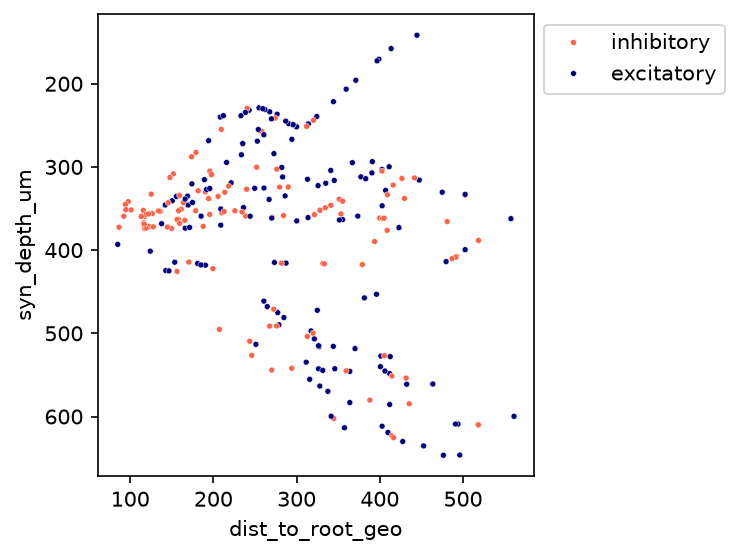

In [49]:
# Extract the depth of each synapse
pre_syn_df["syn_depth_um"] = v1dd_ds.transform("nm").apply_dataframe(
    "ctr_pt_position", pre_syn_df, projection="y"
)

# Restrict to only those cells with a target
pre_syn_df_ct = pre_syn_df.dropna(subset="synapse_target_class")

fig, ax = plt.subplots(figsize=(5, 4), dpi=150)

sns.scatterplot(
    y="syn_depth_um",
    x=distance_column,
    data=pre_syn_df_ct,
    hue="synapse_target_class",
    palette={"excitatory": exc_color, "inhibitory": inh_color},
    ax=ax,
    s=8,
)

ax.invert_yaxis()
ax.set_aspect("equal")
ax.legend().set_bbox_to_anchor((1, 1))

<Axes: xlabel='dist_to_root_geo', ylabel='synapse_target_class'>

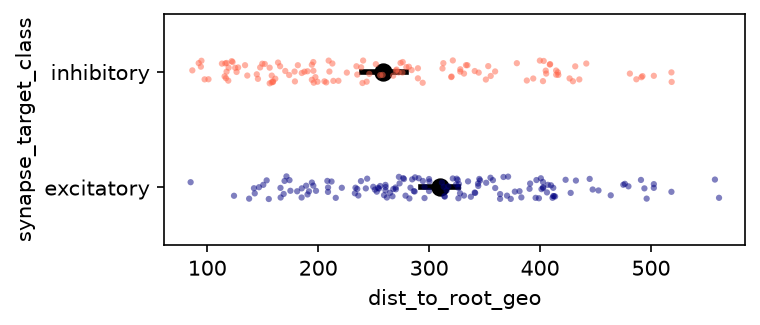

In [50]:
fig, ax = plt.subplots(figsize=(5, 2), dpi=150)
sns.stripplot(
    x=distance_column,
    y="synapse_target_class",
    data=pre_syn_df_ct,
    hue="synapse_target_class",
    palette={"inhibitory": inh_color, "excitatory": exc_color},
    s=3,
    alpha=0.5,
)

sns.pointplot(
    x=distance_column,
    y="synapse_target_class",
    data=pre_syn_df_ct,
    color="k",
    linestyle="none",
)


<Axes: xlabel='dist_to_root_geo', ylabel='Count'>

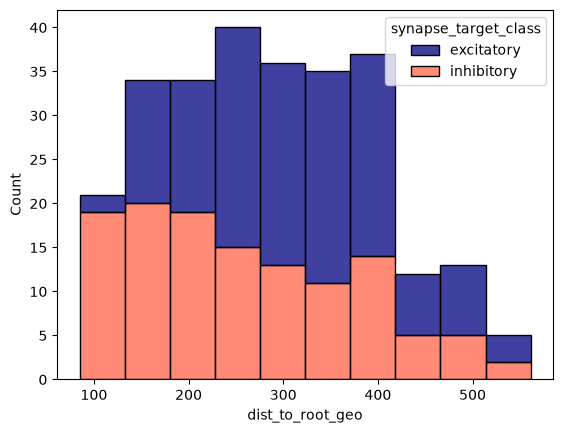

In [51]:
sns.histplot(
    x=distance_column,
    hue="synapse_target_class",
    multiple="stack",
    data=pre_syn_df,
    palette={"excitatory": exc_color, "inhibitory": inh_color},
    hue_order=["excitatory", "inhibitory"],
)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Approach 1: Binned inhibitory targeting fraction </h3>
<p>Our first approach will be to split synapses into distance bins. For each bin, we will treat the fraction of inhibitory targets as arising from a binomial process and estimate the probability.

</div>

In [52]:
# 10 bins along the first 300 microns of synapse-rich axon.

bins = np.linspace(
    pre_syn_df_ct[distance_column].min(),
    pre_syn_df_ct[distance_column].min() + 401,
    10,
)

In [53]:
ds = pre_syn_df_ct[distance_column]
is_inhib = pre_syn_df_ct["synapse_target_class"] == "inhibitory"

k, _, _ = stats.binned_statistic(ds, is_inhib, "sum", bins=bins)
n, _, _ = stats.binned_statistic(ds, is_inhib, "count", bins=bins)

binom_res_inh = stats.binomtest(k=k, n=n)

# Handy for plots

bin_centers = bins[:-1] + np.diff(bins) / 2
binom_res_exc = stats.binomtest(k=n - k, n=n)

In [54]:
# Make a function that plots the estimated probability and confidence interval from a scipy binomial test


def plot_binom_filled(
    x,
    binom_res,
    color=None,
    linewidth=1,
    fill_alpha=0.25,
    method="wilson",
    ax=None,
    line_kwargs=None,
    fill_kwargs=None,
):
    """
    Parameters
    ----------
    x: np.ndarray
        X-axis locations associated with the binomial test
    binom_res:
        Results of scipy.stats.binomtest
    color: list or str
        Matplotlib-interpretable color
    linewidth:
        Width of the estimate line
    fill_alpha:
        Opacity of the confidence interval fill
    method:
        Method for confidence interal, by default "wilson"
    ax:
        matplotlib axis
    line_kwargs:
        Additional dictionary of keywords for the estimate plot (see ax.plot)
    fill_kwarg:
        Additional dictionary of keywords for the confidence interval plot (see ax.fill_between)
    """

    if ax is None:
        ax = plt.gca()
    if line_kwargs is None:
        line_kwargs = {}
    if fill_kwargs is None:
        fill_kwargs = {}

    ax.fill_between(
        x,
        binom_res.proportion_ci(method=method).low,
        binom_res.proportion_ci(method=method).high,
        color=color,
        alpha=fill_alpha,
        **fill_kwargs,
    )
    ax.plot(
        x,
        binom_res.proportion_estimate,
        color=color,
        linewidth=linewidth,
        **line_kwargs,
    )
    return ax

<Axes: >

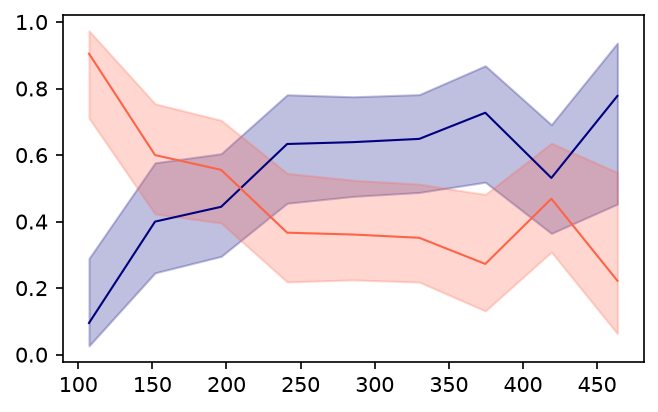

In [55]:
fig, ax = plt.subplots(figsize=(5, 3), dpi=150)

plot_binom_filled(
    bin_centers,
    binom_res_exc,
    ax=ax,
    color=exc_color,
)

plot_binom_filled(
    bin_centers,
    binom_res_inh,
    ax=ax,
    color=inh_color,
)

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Questions:</b>
<p>1) What are the weaknesses and assumptions of this approach? 2) Look at other cells. How typical is this range? 3) What do you notice about the typical pattern of where synapses are and where the crossover between inhibitory and excitatory targets is? 4) If you have time, use the cell type field (not just "classification") to explore if any specific inhibitory subclass drives this effect?

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Approach 2: Fit all the data together </h3>
<p>It looks like the probability of a synapse being inhibitory is monotonic, with a value generally decreasing and stabilizing to some steady value with distance.
<p>We can model this by fitting all the points to a sigmoidal curve, which is a generic S-like shape that smoothly steps from one value to another.
<p>Unlike the binned data, a fitting-based approach accounts for both the exact distances and the amount of data available along the range of distances.
<p>To start, we need a way to parameterize the sigmoidal function. A typical approach is as follows:
<p>If we assume that the probability of a synapse being inhibitory at a given distance follows a sigmoidal function, there are two parameters to fit, which we call $\beta_0$ and $\beta_1$. $$p(s_{inhib} \mid d) = \frac{(p_{i}-p_{lo})}{1 + e^{-(\beta_0 + \beta_1 d)}} + p_{lo}$$
<p>The values all have meanings. $p_{lo}$ is the probability at very low values of distance, $p_{hi}$ is the probability at high values of distance, $\beta_0$ sets where the crossover happens while $\beta_1$ says how fast the crossover happens, and in which direction. Negative values mean the probability decreases with distance, positive values indicate it increases with distance.
<p>A standard approach to fitting data is figure out what parameters $\beta_0$ and $\beta_1$ maximum the probability of the data points. This is <i>maximum likelihood estimatation</i>. In practice, we typically minimize the negative of the log of the probability, simply because that is an easier number to work with and has the same answer.

</div>

In [56]:
from scipy.special import expit  # Numerically stable version of 1 / (1 + exp(-z))
from scipy.optimize import minimize


def sigmoid_prob_is_inhib(beta, ds):
    """beta = [beta_0, beta_1, p_lo, p_hi]

    p_lo, p_hi are the asymptotes of the sigmoid: p -> p_hi in the direction
    of increasing (beta_0 + beta_1 * ds), p -> p_lo in the other.

    With beta_1 < 0 (as in the fit above), increasing distance means
    decreasing z, so:
        p_lo = p(inhib | ds -> +inf)   <- the distal floor, your A_inf
        p_hi = p(inhib | ds -> -inf)   <- the proximal ceiling
    """
    b0, b1, p_lo, p_hi = beta
    return p_lo + (p_hi - p_lo) * expit(b0 + b1 * ds)


def sigmoid_log_loss(beta, ds, value):
    """Negative log likelihood"""
    p = sigmoid_prob_is_inhib(beta, ds)
    p = np.clip(
        p, 1e-12, 1 - 1e-12
    )  # Don't let values get to 0/1 if p_lo == 0 or p_hi == 1
    return -np.sum(value * np.log(p) + (1 - value) * np.log(1 - p))


Text(0.5, 0, 'dist_to_root_geo')

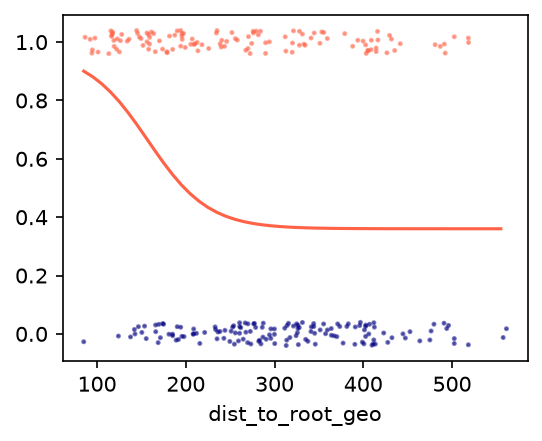

In [57]:
## Do the fit
distance_column = "dist_to_root_geo"
ds = pre_syn_df_ct[distance_column]
is_inhib = pre_syn_df_ct["synapse_target_class"] == "inhibitory"

fit = minimize(
    sigmoid_log_loss,
    [0, 0, 0.05, 0.95],  # Initial guesses
    args=(ds, is_inhib),  # Data
)

## Plot the results

x_grid = np.arange(
    pre_syn_df_ct[distance_column].min(), pre_syn_df_ct[distance_column].max(), 10
)

fig, ax = plt.subplots(figsize=(4, 3), dpi=150)
ax.plot(x_grid, sigmoid_prob_is_inhib(fit.x, x_grid), color=inh_color)

rng = np.random.default_rng(0)
jit = rng.uniform(-0.04, 0.04, len(is_inhib))
ax.scatter(
    ds,
    is_inhib + jit,
    s=2,
    alpha=0.5,
    c=np.where(is_inhib, inh_color, exc_color),
)
ax.set_xlabel(distance_column)

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Questions</b>
<ol>
<li>Does this hold with other cells?
<li>Consider both the trends and the absolute numbers. What assumptions are required for this analysis to be correct? Do you think these hold in practice?
<li>What about inhibitory cells?
<li>How do all of these functions behave if we chose different distance functions? What do you think that means biologically?
<li>Can you think of any other ways to split up the connections for these cells?
<li>This sigmoidal fit was just one model of how connections form and are distributed across an arbor. What aspects of the data does it capture, and which does it not?
<li>Can you think of different models that might approach this data differently?
</ol>

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h4> Sanity checking the results by looking at the data </h4>

</div>

In [58]:
from nglui.statebuilder import ViewerState

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>We can start with a very basic neuroglancer link to the dataset based on the info stored in the CAVEclient

</div>

In [59]:
viewer = ViewerState(client=client).add_layers_from_client()
viewer.to_link()

Using default Google credentials. There is no ~/.cloudvolume/secrets/google-secret.json set.

        google-cloud-python might not find your credentials. Your credentials
        might be located in $HOME/.config/gcloud/legacy_credentials/$YOUR_GMAIL/adc.json

        If they are you can export your credentials like so:
        export GOOGLE_APPLICATION_CREDENTIALS="$HOME/.config/gcloud/legacy_credentials/$YOUR_GMAIL/adc.json"
      
Using default Google credentials. There is no ~/.cloudvolume/secrets/google-secret.json set.

        google-cloud-python might not find your credentials. Your credentials
        might be located in $HOME/.config/gcloud/legacy_credentials/$YOUR_GMAIL/adc.json

        If they are you can export your credentials like so:
        export GOOGLE_APPLICATION_CREDENTIALS="$HOME/.config/gcloud/legacy_credentials/$YOUR_GMAIL/adc.json"
      


In [60]:
(
    ViewerState(client=client)
    .add_layers_from_client()
    .add_segments(
        [root_id], segment_colors="white"
    )  # Add our root id and set the color to white
    .add_annotation_layer(
        "inh_targeting",  # Add a new annotation layer to put inhibitory-targeting points.
        linked_segmentation="segmentation",  # Attach it to the layer "segmentation" so that segment ids can be loaded
        color=inh_color,  # Set the base color of annotations
    )
    .add_points(  # Add points based on a dataframe
        data=pre_syn_df_ct.query('synapse_target_class == "inhibitory"'),
        name="inh_targeting",  # Add points to the layer above, which was named "inh_targeting"
        point_column="post_pt_position",  # Use the `post_pt_position` column to find locations to add points
        segment_column="post_pt_root_id",  # Use the `post_pt_root_id` column to associate a target segment with the point
        data_resolution=[
            1,
            1,
            1,
        ],  # Note that points are in nm, allowing the tool to put them in the right location in neuroglancer space
    )
    .add_annotation_layer(  # Do the same thing again for excitatory-targeting synapses
        "exc_targeting",
        linked_segmentation="segmentation",
        color="cyan",
    )
    .add_points(
        data=pre_syn_df_ct.query('synapse_target_class == "excitatory"'),
        name="exc_targeting",
        point_column="post_pt_position",
        segment_column="post_pt_root_id",
        data_resolution=[1, 1, 1],
    )
).to_link()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Additional Ideas </h2>
<p>1) The Schmidt et al. paper measures a few other aspects of neuronal connectivity, such as the clustering of synapses in the same connection and the connectivity of the target neuron. Read that paper and think about how its approach might relate to the EM datasets.
<p>2) Another interesting kind of distance is <a href="https://pages.ucsd.edu/~msereno/systneurosci/readings/01.00-DendriteSpikeSyn.pdf">Electrotonic Distance</a>, which measures how much a voltage signal attenuates across a neuronal arbor with passive ion channels. Electrotonic distance incorporates dendritic radius, branching structure, and membrane properties in a manner that allows one to estimate dendritic integration. On a similar vein, <a href="https://www.cell.com/neuron/fulltext/S0896-62732500429-5?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0896627325004295%3Fshowall%3Dtrue">Morabito et al. 2025</a> used the MICrONS dataset to identify some interesting differences in dendritic integration propertie of inhibitory subclasses.
<p>3) How do different neurons differ in how they connect to their targets? For example, do they make repeated sets of synapses onto the same target, or distribute them more randomly? What might different rules mean for circuit structure?

</div>